In [1]:
import mne
import mne_connectivity

print("MNE:", mne.__version__)
print("MNE-Connectivity:", mne_connectivity.__version__)

AttributeError: module 'pandas.arrays' has no attribute 'NumpyExtensionArray'

In [1]:
import pandas as pd 
import os
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau
import networkx as nx
import igraph as ig
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score,roc_auc_score,f1_score,RocCurveDisplay,roc_curve,auc
import seaborn as sns
from scipy.signal import butter, sosfilt,lfilter, lfilter_zi,lfilter_zi, iirnotch, freqz, filtfilt
import sys
from scipy.signal import sosfiltfilt, hilbert
from scipy.stats import pearsonr
#from mne_connectivity import spectral_connectivity_epochs  

In [2]:
import pkg_resources
import scipy
import sklearn
libraries = ['pandas', 'numpy', 'scipy', 'networkx']  # sostituisci con le librerie di cui ti interessa conoscere la versione

for library in libraries:
    version = pkg_resources.get_distribution(library).version
    print(f'{library}=={version}')
print('scikit-learn=={}.'.format(sklearn.__version__))


pandas==1.3.3
numpy==1.24.4
scipy==1.10.1
networkx==2.8.3
scikit-learn==1.3.2.


In [8]:
###folder_name='/Users/donato/Library/CloudStorage/OneDrive-UniversitàdegliStudidiBari/Phd/EEG/Dataset_SanDiego'
#QUANDO USAVO IL DRIVE OneDrive-UniversitàdegliStudidiBari

In [3]:
folder_name='/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/Phd/EEG/Dataset_SanDiego'

In [9]:
'''
Read the path where the processed files have been stored
'''
# Folder Path
path = folder_name              
os.chdir(path)     
#%% read file
'''
read the file of all subjects of the San Diego dataset
'''
time=1/511 
def read_text_file(file_path):
    with open(file_path, 'r') as f:
        print(f.read())
        
df_eeg=[]
for file in os.listdir():
    if file.startswith('processed'):
        subject=file[14:]
        if subject.startswith('pd'):
            label=1#pd
        else:
            label=0#hc           
        print(file)
        file_path=f"{path}/{file}"        
        data_eeg=pd.read_csv(file_path,sep='\t')
        data_eeg.Time=data_eeg.Time*time
        #data_eeg['Label']=label
        data_eeg.insert(0,'subject',subject)
        data_eeg.insert(1,'Label',label)
        df_eeg.append(data_eeg)       
df_eeg = pd.concat(df_eeg)
df_eeg=df_eeg.drop(columns=["EXG1","EXG2","EXG3","EXG4","EXG5","EXG6","EXG7"])
df_eeg=df_eeg.sort_values(by=['subject','Time'])

                                ##LA SELEZIONE DELLE BANDE NON SERVE IN QUESTO CODICE
#%%
#select the band

band_selected=='theta'

if band_selected=='beta':
    low_cut = 13
    high_cut= 32
elif band_selected=='alpha':
    low_cut = 8
    high_cut= 12
elif band_selected=='delta':
    low_cut = 1
    high_cut= 4
elif band_selected=='gamma':
    low_cut = 30
    high_cut= 100
elif band_selected=='theta':
    low_cut = 4
    high_cut= 7


filter_order=4
order=int(filter_order)
#create the filter    
        
sampling_frequency=511
eeg_filter_data=pd.DataFrame(columns=df_eeg.columns)
eeg_filter_data['subject']=df_eeg.subject
eeg_filter_data['Label']=df_eeg.Label
eeg_filter_data['Time']=df_eeg.Time


sub_list=np.unique(df_eeg.subject)
filter_data = butter_bandpass_filter(data = eegdata_mean_smooth[' EXG Channel 3'].values, lowcut = 0.5, highcut= 50, fs = sampling_frequency, order = 3)
df_drop=df_eeg.drop(['subject','Label','Time'],axis=1)

for sub in sub_list:
     print('subject: ', sub)
     for col in df_eeg.columns:
        if ((df_eeg.columns!='subject').any() and (df_eeg.columns!='Label').any() and (df_eeg.columns!='Time').any):
         if ((col!='subject') and (col!='Label') and (col!='Time')) :
             print('columns: ', col)
             #eeg_filter_data[eeg_filter_data.subject==sub][col]
             print(eeg_filter_data.iloc[sub][col])
             eeg_filter_data.loc[eeg_filter_data.subject==sub][col]=butter_bandpass_filter(data = df_eeg.loc[df_eeg.subject==sub][col].values, lowcut = 13, highcut= 32, fs = sampling_frequency, order = 3)
           
            #=(butter_bandpass_filter(data = df_drop[col].values, lowcut = 13, highcut= 32, fs = sampling_frequency, order = 3))

for col in df_eeg.columns:
    if ((col!='subject') and (col!='Label') and (col!='Time')) :
        dummy=[]
        #print(col)
        for sub in sub_list:
            #print(df_eeg.loc[df_eeg.subject==sub][col].values)
            dummy=np.concatenate((dummy,butter_bandpass_filter(data = df_eeg.loc[df_eeg.subject==sub][col].values, lowcut = low_cut, highcut= high_cut, fs = sampling_frequency, order = order)),axis=0)
        eeg_filter_data[col]=dummy
####eeg_filter_data.to_csv('/Users/donato/Library/CloudStorage/OneDrive-UniversitàdegliStudidiBari/Phd/EEG/Segnale_in_bande_con_codice_Federica/eeg_data_'+band_selected+'_'+str(filter_order)+'.csv' )
#%%

eeg_filter_data=df_eeg.copy()
'''
Create the complex network and extract features per each node
part1: preparation of some lists
'''
channel=list(np.unique(eeg_filter_data.iloc[:,3:].columns))
sub_list=np.unique(eeg_filter_data.subject)
df_eeg_sub=eeg_filter_data.set_index('subject') #set subject as index
sub_label=np.unique(eeg_filter_data.Label)
sub_pd=[]
sub_hc=[]

for i in range(len(sub_list)):
    if sub_list[i].startswith('pd'):
        sub_pd.append(sub_list[i])
    else:
        sub_hc.append(sub_list[i])
        
feat_list=['degree','betwcentr','clustering','egvcentr','information','closeness','eccentricity','assortativity','edge_btw','transitivity']

ch_ft_degree=[]
ch_ft_betw=[]
ch_ft_cl=[]
ch_ft_eig=[]
ch_ft_info=[]
ch_ft_close=[]
ch_ft_ecc=[]
ch_ft_ass=[]
ch_ft_edge_btw=[]
ch_ft_trans=[]

channel.sort()

for ch in range(0,len(channel)):
    ch_ft_degree.append(channel[ch]+'_'+feat_list[0])
    ch_ft_betw.append(channel[ch]+'_'+feat_list[1])
    ch_ft_cl.append(channel[ch]+'_'+feat_list[2])
    ch_ft_eig.append(channel[ch]+'_'+feat_list[3])
    ch_ft_info.append(channel[ch]+'_'+feat_list[4])
    ch_ft_close.append(channel[ch]+'_'+feat_list[5])
    ch_ft_ecc.append(channel[ch]+'_'+feat_list[6])

processed_sub_hc30
processed_sub_hc31
processed_sub_pd23
processed_sub_pd12
processed_sub_hc4
processed_sub_pd14
processed_sub_pd13
processed_sub_pd22
processed_sub_hc2
processed_sub_pd3
processed_sub_hc25
processed_sub_pd5
processed_sub_hc24
processed_sub_hc33
processed_sub_hc32
processed_sub_hc7
processed_sub_pd16
processed_sub_pd11
processed_sub_hc1
processed_sub_hc8
processed_sub_pd17
processed_sub_pd28
processed_sub_pd26
processed_sub_pd19
processed_sub_hc10
processed_sub_hc21
processed_sub_pd9
processed_sub_hc18
processed_sub_hc20
processed_sub_hc29
processed_sub_pd6


NameError: name 'band_selected' is not defined

In [14]:
df_eeg_sub

,Label,Time,Fp1,AF3,F3,FC1,FC5,T7,C3,CP1,...,FC2,F4,F8,AF4,Fp2,Fz,Cz,F7,FC6,T8
subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,0.000000,-15.9563,-9.2983,NaN,-7.5893,4.9980,6.7107,0.9440,0.4314,...,-7.7523,-20.5794,-11.0188,-13.9028,-32.6759,-9.0773,-7.9292,-5.2976,-1.9926,10.9390
hc1,0,0.003822,-20.5820,0.9234,NaN,-3.7111,-1.9821,4.0416,0.6984,2.3547,...,-5.3719,-21.8556,-6.1082,-12.7041,-30.7657,-7.1173,-4.8919,0.8333,-7.9833,11.5309
hc1,0,0.007644,-18.4827,-7.8092,NaN,-0.7867,-1.8810,5.4743,2.9300,5.2588,...,-2.6337,-20.5005,-1.2981,-10.9186,-26.0861,-4.4810,0.1163,8.2255,-12.4959,3.8165
hc1,0,0.011467,-18.5126,-26.5763,NaN,1.6704,-3.8375,8.5220,4.9438,5.5872,...,0.3410,-16.7349,1.1459,-10.3115,-20.1357,-2.4667,2.9641,5.6483,-7.1327,0.7927
hc1,0,0.015289,-20.0873,-40.1946,NaN,2.3968,-3.1339,11.3055,7.5462,4.3205,...,4.0080,-11.8643,3.6064,-7.0630,-19.9575,-0.5767,2.8549,4.2207,2.2664,8.6005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pd9,1,261.628165,1.4116,3.6035,5.5428,7.8848,2.2158,-9.1536,0.7770,-1.7050,...,NaN,NaN,-8.2136,3.3496,-0.5580,9.5535,-0.3943,NaN,NaN,0.4465
pd9,1,261.631987,-0.5274,2.2041,3.5821,6.1907,-0.2041,-10.6922,-0.6775,-2.7586,...,NaN,NaN,-8.7010,3.5946,-1.3602,8.3040,-2.0594,NaN,NaN,1.2977
pd9,1,261.635809,-1.5021,1.6716,2.5649,5.5284,-0.6375,-9.9759,-0.9622,-2.6007,...,NaN,NaN,-7.2381,2.2705,0.6645,7.6150,-2.4311,NaN,NaN,1.7754


## SPEARMAN

In [5]:
#%% complex network

df_dg=pd.DataFrame(columns=[ch_ft_degree])
df_dg.insert(0,'Subject','')
df_dg.insert(1,'Label','')

df_cl=pd.DataFrame(columns=[ch_ft_cl])
df_cl.insert(0,'Subject','')
df_cl.insert(1,'Label','')

df_bt=pd.DataFrame(columns=[ch_ft_betw])
df_bt.insert(0,'Subject','')
df_bt.insert(1,'Label','')

df_egv=pd.DataFrame(columns=[ch_ft_eig])
df_egv.insert(0,'Subject','')
df_egv.insert(1,'Label','')

df_inf_cent=pd.DataFrame(columns=[ch_ft_info])
df_inf_cent.insert(0,'Subject','')
df_inf_cent.insert(1,'Label','')

df_close=pd.DataFrame(columns=[ch_ft_close])
df_close.insert(0,'Subject','')
df_close.insert(1,'Label','')

df_ecc=pd.DataFrame(columns=[ch_ft_ecc])
df_ecc.insert(0,'Subject','')
df_ecc.insert(1,'Label','')


#Dataframe for edge betweennes
df_edge_btw=pd.DataFrame()

#%%
#list necessary for plotting graph
graph_pd=[]
graph_hc=[]
for sub in sub_list:
    df_eeg_subject=df_eeg_sub.loc[[sub]]#dataframe per subject
   
    df=pd.DataFrame(index=channel,columns=range(len(df_eeg_subject['Fp1'].values)))
    
    for ch in channel:
        df.loc[[ch]]=df_eeg_subject[ch].values
    
#    print(df)
#     #complex network
    df_nodes=pd.DataFrame(columns=['Id'],dtype=object)#empty dataframe for nodes
    
    for ch in channel:
        df_nodes=df_nodes.append({'Id':ch},ignore_index=True)
    print(df_nodes)
    
#     #Network with Pearson correlation
#     #source=first node
#     #target=note to be correlated
#     #Weight=pearson coefficient
    df_links_pearson=pd.DataFrame(columns=['Source','Target','Weight','p-value'],dtype=object)
    
    for ch1, index_ch1 in zip(channel,range(len(channel))):        
        indicators1 = df.loc[ch1].values.astype(float)
        for ch2 in channel[:index_ch1]:#tutti i canali tranne se stesso
            indicators2 = df.loc[ch2].values.astype(float)
            # nans = np.where(np.logical_or(np.isnan(indicators1),np.isnan(indicators2)))
            # indicators1_without_common_nans = [indicators1[i] for i in range(len(indicators1)) if np.isin(i,nans)==False]
            # indicators2_without_common_nans = [indicators2[i] for i in range(len(indicators2)) if np.isin(i,nans)==False]
            # # calculate Pearson's correlation
            # print('sub ',sub,' ch1 ',ch1,' indicator 1 ',len(indicators1_without_common_nans))
            # print('sub ',sub,' ch2 ',ch2,' indicator 2 ',len(indicators2_without_common_nans))           
            # if (len(indicators1_without_common_nans)!=0 or len(indicators2_without_common_nans)!=0):
            #     cor_coef, p = pearsonr(indicators1_without_common_nans, indicators2_without_common_nans)            
            #     #print('Channel: ',ch1,' and ',ch2,' -- Pearson\'s correlation coefficient: %.3f' % cor_coef)
            #     alpha = 10**(-2)
                
            #     if p > alpha: # alpha is the significance threshold
            #         print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
            #     else:
            #         print('Samples are correlated (reject H0) p=%.3f' % p)
            #         df_links_pearson = df_links_pearson.append({'Source': ch1, 'Target': ch2, 'Weight': np.absolute(cor_coef), 'p-value': p}, ignore_index=True)        
                    
                
            # else:
            #     df_links_pearson = df_links_pearson.append({'Source': ch1, 'Target': ch2, 'Weight': np.nan, 'p-value': np.nan}, ignore_index=True)                
    
            cor_coef, p = spearmanr(indicators1, indicators2,nan_policy='propagate')            
            
            alpha = 10**(-2)
            
            if p > alpha: # alpha is the significance threshold
                print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
            else:
                print('Samples are correlated (reject H0) p=%.3f' % p)
                df_links_pearson = df_links_pearson.append({'Source': ch1, 'Target': ch2, 'Weight': np.absolute(cor_coef), 'p-value': p}, ignore_index=True)        

    print(df_links_pearson)
       
    UN_net = nx.Graph() #for of subject
    UN_net.add_nodes_from(df_nodes['Id'])
    
    
    df_links = pd.DataFrame(columns = ['source','target','weight'], dtype=object)
    df_links['source'] = df_links_pearson['Source']
    df_links['target'] = df_links_pearson['Target']
    df_links['weight'] = df_links_pearson['Weight']
    df_links=df_links.dropna()
    UN_net = nx.from_pandas_edgelist(df_links, edge_attr = True)

    if sub.startswith('pd'):
        graph_pd.append(UN_net)
    if sub.startswith('hc'):
        graph_hc.append(UN_net)
        
#dictionary for degree
    dict_degree=dict(dict(UN_net.degree(weight='weight')))
    dict_keys_list = list(dict_degree.keys())
    dict_keys_list.sort()
    set1=set(channel)
    set2=set(dict_keys_list)
    missing=list(sorted(set1-set2))
    for i in range(len(missing)):
        dict_degree[missing[i]]='NaN'
  
    dict_keys_list=list(dict_degree.keys())
    dict_keys_list.sort()
    dict_degree = {i: dict_degree[i] for i in dict_keys_list}   
    degree=list(dict_degree.values())
    
#dictionary for betweennes
    dict_btw=dict(dict(nx.betweenness_centrality(UN_net,weight='weight')))
    dict_keys_list_btw = list(dict_btw.keys())
    dict_keys_list_btw.sort()
    set1_btw=set(channel)
    set2_btw=set(dict_keys_list_btw)
    missing_btw=list(sorted(set1_btw-set2_btw))
    for i in range(len(missing_btw)):
        dict_btw[missing_btw[i]]='NaN'
  
    dict_keys_list_btw=list(dict_btw.keys())
    dict_keys_list_btw.sort()
    dict_btw = {i: dict_btw[i] for i in dict_keys_list_btw}   
    betweenness_centrality=list(dict_btw.values())
   
#dictionary for clustering
    dict_clt=dict(dict(nx.clustering(UN_net,weight='weight')))
    dict_keys_list_clt = list(dict_clt.keys())
    dict_keys_list_clt.sort()
    set1_clt=set(channel)
    set2_clt=set(dict_keys_list_clt)
    missing_clt=list(sorted(set1_clt-set2_clt))
    for i in range(len(missing_clt)):
        dict_clt[missing_clt[i]]='NaN'
  
    dict_keys_list_clt=list(dict_clt.keys())
    dict_keys_list_clt.sort()
    dict_clt = {i: dict_clt[i] for i in dict_keys_list_clt}   
    coeff_clustering=list(dict_clt.values())
        
#dictionary for eigenvector_centrality
    dict_egv=dict(dict(nx.eigenvector_centrality(UN_net,weight='weight')))
    dict_keys_list_egv = list(dict_egv.keys())
    dict_keys_list_egv.sort()
    set1_egv=set(channel)
    set2_egv=set(dict_keys_list_egv)
    missing_egv=list(sorted(set1_egv-set2_egv))
    for i in range(len(missing_egv)):
        dict_egv[missing_egv[i]]='NaN'
  
    dict_keys_list_egv=list(dict_egv.keys())
    dict_keys_list_egv.sort()
    dict_egv = {i: dict_egv[i] for i in dict_keys_list_egv}   
    eigenvector_centrality=list(dict_egv.values())

    
# #dictionary for information centrality 

    dict_info=dict(dict(nx.information_centrality(UN_net,weight='weight')))
    dict_keys_list_info = list(dict_info.keys())
    dict_keys_list_info.sort()
    set1_info=set(channel)
    set2_info=set(dict_keys_list_info)
    missing_info=list(sorted(set1_info-set2_info))
    for i in range(len(missing_info)):
        dict_info[missing_info[i]]='NaN'

    dict_keys_list_info=list(dict_info.keys())
    dict_keys_list_info.sort()
    dict_info = {i: dict_info[i] for i in dict_keys_list_info}   
    info_centrality=list(dict_info.values())
    

#dictionary for communicability

    dict_close=nx.closeness_centrality(UN_net)
    dict_keys_list_close = list(dict_close.keys())
    dict_keys_list_close.sort()
    set1_close=set(channel)
    set2_close=set(dict_keys_list_close)
    missing_comm=list(sorted(set1_close-set2_close))
    for i in range(len(missing_comm)):
        dict_close[missing_comm[i]]='NaN'

    dict_keys_list_close=list(dict_close.keys())
    dict_keys_list_close.sort()
    dict_close = {i: dict_close[i] for i in dict_keys_list_close}   
    closeness=list(dict_close.values())


#dictionary for eccentricity

    dict_ecc=dict(dict(nx.eccentricity(UN_net)))
    dict_keys_list_ecc = list(dict_ecc.keys())
    dict_keys_list_ecc.sort()
    set1_ecc=set(channel)
    set2_ecc=set(dict_keys_list_ecc)
    missing_ecc=list(sorted(set1_ecc-set2_ecc))
    for i in range(len(missing_ecc)):
        dict_ecc[missing_ecc[i]]='NaN'

    dict_keys_list_ecc=list(dict_ecc.keys())
    dict_keys_list_ecc.sort()
    dict_ecc = {i: dict_ecc[i] for i in dict_keys_list_ecc}   
    eccentricity=list(dict_ecc.values())

#dataframe for edge betweenness centrality
    
    # edg_bt_series=pd.Series(dict(
    #         betweenness = nx.edge_betweenness_centrality(UN_net,weight='weight')
    #     ))
    # df_edg_btw=pd.DataFrame(dict(
    #         betweenness = nx.edge_betweenness_centrality(UN_net,weight='weight')
    #     )).T
    # df_edg_btw.append(df_edg_btw)
    # df = pd.DataFrame.from_dict(dict(
    #         betweenness = nx.edge_betweenness_centrality(UN_net,weight='weight')
    #     ), orient = 'index')
    df_edge_btw=df_edge_btw.append(pd.DataFrame.from_dict(dict(
            betweenness = nx.edge_betweenness_centrality(UN_net,weight='weight')
        ), orient = 'index'))
    print('sub' , sub)
    # df1.columns = ['_'.join(col) for col in df1.columns.values]
    # #df_edg_btw.columns = ['Egde_btw_'+col for col in df_edg_btw.columns.values]
    df_edge_btw= df_edge_btw.reset_index(drop=True)
    # df1['Subject']=sub
    # df1.insert(1,'Label',df_eeg_subject.Label.values[0])


    

    flat_degree=[]
    flat_degree.append(sub)
    flat_degree.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(degree)):
        flat_degree.append(degree[i])
        
    flat_betwennes=[]
    flat_betwennes.append(sub)
    flat_betwennes.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(betweenness_centrality)):
        flat_betwennes.append(betweenness_centrality[i])
  
    flat_clustering=[]
    flat_clustering.append(sub)
    flat_clustering.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(coeff_clustering)):
        flat_clustering.append(coeff_clustering[i])

    flat_eigenvector=[]
    flat_eigenvector.append(sub)
    flat_eigenvector.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(eigenvector_centrality)):
        flat_eigenvector.append(eigenvector_centrality[i])
        
    flat_info=[]
    flat_info.append(sub)
    flat_info.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(info_centrality)):
        flat_info.append(info_centrality[i])
        
         
    flat_close=[]
    flat_close.append(sub)
    flat_close.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(closeness)):
        flat_close.append(closeness[i])       
                        
    flat_ecc=[]
    flat_ecc.append(sub)
    flat_ecc.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(eccentricity)):
        flat_ecc.append(eccentricity[i])        
    
        
    df_dg=df_dg.append(pd.DataFrame(np.array(flat_degree).reshape(1,-1),columns=list(df_dg.columns)),ignore_index=True)
    df_cl=df_cl.append(pd.DataFrame(np.array(flat_clustering).reshape(1,-1),columns=list(df_cl.columns)),ignore_index=True)
    df_bt=df_bt.append(pd.DataFrame(np.array(flat_betwennes).reshape(1,-1),columns=list(df_bt.columns)),ignore_index=True)
    df_egv=df_egv.append(pd.DataFrame(np.array(flat_eigenvector).reshape(1,-1),columns=list(df_egv.columns)),ignore_index=True)
 
    df_inf_cent=df_inf_cent.append(pd.DataFrame(np.array(flat_info).reshape(1,-1),columns=list(df_inf_cent.columns)),ignore_index=True)
    df_close=df_close.append(pd.DataFrame(np.array(flat_close).reshape(1,-1),columns=list(df_close.columns)),ignore_index=True)
    df_ecc=df_ecc.append(pd.DataFrame(np.array(flat_ecc).reshape(1,-1),columns=list(df_ecc.columns)),ignore_index=True)
    
    
# df_edge_btw=df_edge_btw.insert(0,'Subject',sub_list)
# df_edge_btw=df_edge_btw.insert(1,'Label',sub_label)
df_edge_btw.columns = ['_'.join(col) for col in df_edge_btw.columns.values]
df_edge_btw.insert(0,'Subject',sub_list)
#%% store features of degree in a csv file
df_dg.columns = df_dg.columns.get_level_values(0)
df_cl.columns = df_cl.columns.get_level_values(0)
df_bt.columns = df_bt.columns.get_level_values(0)
df_inf_cent.columns = df_inf_cent.columns.get_level_values(0)
df_egv.columns = df_egv.columns.get_level_values(0)
df_close.columns = df_close.columns.get_level_values(0)
#df_ecc.columns = df_ecc.columns.get_level_values(0)

extracted_col_cl=df_cl.iloc[:,2:]
extracted_col_bt=df_bt.iloc[:,2:]
extracted_col_egv=df_egv.iloc[:,2:]
extracted_col_info=df_inf_cent.iloc[:,2:]
extracted_col_close=df_close.iloc[:,2:]
#extracted_col_ecc=df_ecc.iloc[:,2:]
extracted_col_edge_btw=df_edge_btw.iloc[:,1:]


connectome_feat=df_dg.join(extracted_col_cl)
connectome_feat=connectome_feat.join(extracted_col_bt)
connectome_feat=connectome_feat.join(extracted_col_egv)
connectome_feat=connectome_feat.join(extracted_col_info)
connectome_feat=connectome_feat.join(extracted_col_close)
connectome_feat=connectome_feat.join(extracted_col_edge_btw)

#connectome_feat.to_csv('/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/Phd/EEG/connectome_all_frequencies_metrica.csv')


     Id
0   AF3
1   AF4
2    C3
3    C4
4   CP1
5   CP2
6   CP5
7   CP6
8    Cz
9    F3
10   F4
11   F7
12   F8
13  FC1
14  FC2
15  FC5
16  FC6
17  Fp1
18  Fp2
19   Fz
20   O1
21   O2
22   Oz
23   P3
24   P4
25   P7
26   P8
27  PO3
28  PO4
29   Pz
30   T7
31   T8
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.002
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are uncorrelated (fail to reject H0) p=0.581
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.002
Samples are correlated (reject H0) p=0

<class 'networkx.utils.decorators.argmap'> compilation 32:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


     Id
0   AF3
1   AF4
2    C3
3    C4
4   CP1
5   CP2
6   CP5
7   CP6
8    Cz
9    F3
10   F4
11   F7
12   F8
13  FC1
14  FC2
15  FC5
16  FC6
17  Fp1
18  Fp2
19   Fz
20   O1
21   O2
22   Oz
23   P3
24   P4
25   P7
26   P8
27  PO3
28  PO4
29   Pz
30   T7
31   T8
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.002
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are uncorrelated (fail to reject H0) p=0.591
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0

<class 'networkx.utils.decorators.argmap'> compilation 32:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


sub hc10
     Id
0   AF3
1   AF4
2    C3
3    C4
4   CP1
5   CP2
6   CP5
7   CP6
8    Cz
9    F3
10   F4
11   F7
12   F8
13  FC1
14  FC2
15  FC5
16  FC6
17  Fp1
18  Fp2
19   Fz
20   O1
21   O2
22   Oz
23   P3
24   P4
25   P7
26   P8
27  PO3
28  PO4
29   Pz
30   T7
31   T8
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.

...

<class 'networkx.utils.decorators.argmap'> compilation 32:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


     Id
0   AF3
1   AF4
2    C3
3    C4
4   CP1
5   CP2
6   CP5
7   CP6
8    Cz
9    F3
10   F4
11   F7
12   F8
13  FC1
14  FC2
15  FC5
16  FC6
17  Fp1
18  Fp2
19   Fz
20   O1
21   O2
22   Oz
23   P3
24   P4
25   P7
26   P8
27  PO3
28  PO4
29   Pz
30   T7
31   T8
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.004
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Sampl

<class 'networkx.utils.decorators.argmap'> compilation 32:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


     Id
0   AF3
1   AF4
2    C3
3    C4
4   CP1
5   CP2
6   CP5
7   CP6
8    Cz
9    F3
10   F4
11   F7
12   F8
13  FC1
14  FC2
15  FC5
16  FC6
17  Fp1
18  Fp2
19   Fz
20   O1
21   O2
22   Oz
23   P3
24   P4
25   P7
26   P8
27  PO3
28  PO4
29   Pz
30   T7
31   T8
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=nan
Samples are correlated (reject H0) p=nan
Samples are correlated (reject H0) p=nan
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=nan
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=nan
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are cor

<class 'networkx.utils.decorators.argmap'> compilation 32:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


### Boxplot metriche di rete

TypeError: 'value' must be an instance of str or bytes, not a float

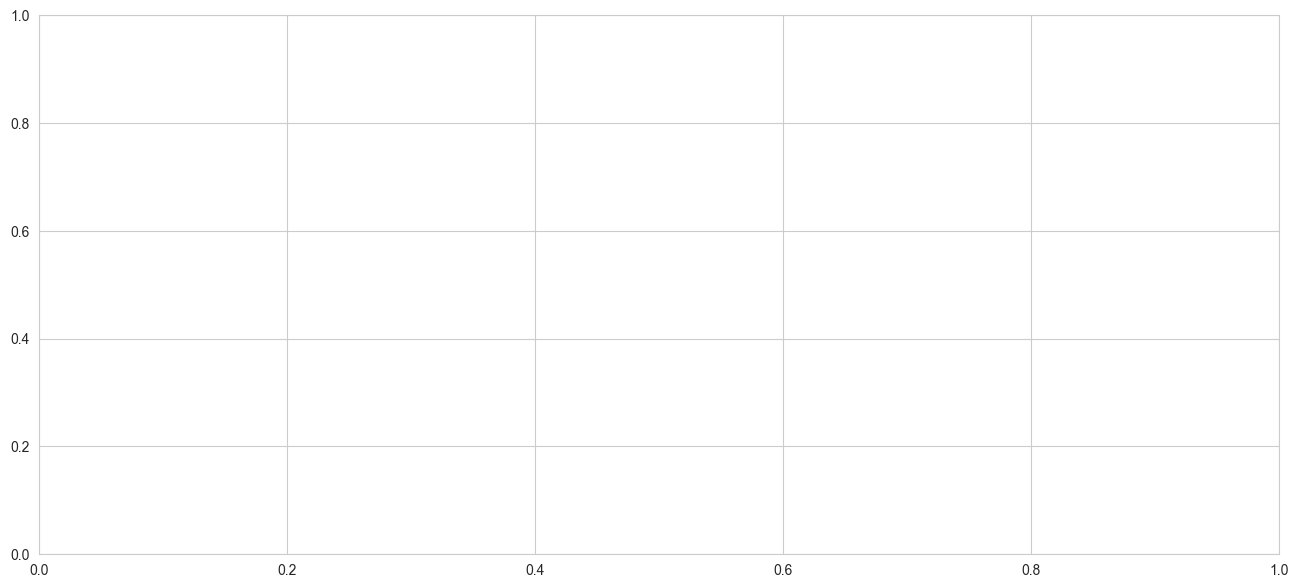

In [13]:
# Copia del dataframe
df_plot = connectome_feat.copy()

# Colonne identificative
id_cols = ['Subject', 'Label']

# Tutte le altre colonne sono metriche
metric_cols = [col for col in df_plot.columns if col not in id_cols]

# Trasformazione da wide a long
df_long = df_plot.melt(
    id_vars=id_cols,
    value_vars=metric_cols,
    var_name='Metric',
    value_name='Value'
)

# Boxplot
plt.figure(figsize=(16, 7))

sns.boxplot(
    data=df_long,
    x='Metric',
    y='Value',
    hue='Label'
)

plt.xlabel('Network Metric')
plt.ylabel('Value')
plt.xticks(rotation=90)
plt.legend(title='Label')
plt.tight_layout()
plt.show()

In [10]:
# Prepara un unico dataframe per tutti i boxplot
all_metrics_long = pd.DataFrame()

for df_metric, metric_name in metrics_data:
    df_temp = df_metric[['Subject', 'Label', 'Mean']].copy()
    df_temp['Metric'] = metric_name
    df_temp['Group'] = df_temp['Label'].map(label_map)
    all_metrics_long = pd.concat([all_metrics_long, df_temp], ignore_index=True)

# Crea il boxplot con hue='Metric' e Groups separati
plt.figure(figsize=(16, 10))

# Usa hue per separare PD e HC all'interno di ogni metrica
sns.boxplot(data=all_metrics_long, x='Metric', y='Mean', hue='Group',
            palette=['#2ecc71', '#e74c3c'], width=0.7)

# Personalizza il grafico
plt.title('Comparison of Network Metrics: PD vs HC', fontsize=16, fontweight='bold')
plt.xlabel('Network Metrics', fontsize=14)
plt.ylabel('Mean Value', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.legend(title='Group', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('network_metrics_boxplot_combined.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'metrics_data' is not defined

In [12]:
df_dg

,Subject,Label,AF3_degree,AF4_degree,C3_degree,C4_degree,CP1_degree,CP2_degree,CP5_degree,CP6_degree,...,Oz_degree,P3_degree,P4_degree,P7_degree,P8_degree,PO3_degree,PO4_degree,Pz_degree,T7_degree,T8_degree
0,hc1,0,4.021866079677694,8.736851248011982,5.170234978108308,8.803919753146577,9.35114257837815,10.003614569701046,7.721435655903978,7.349153455671346,...,9.264170885527095,9.550740206588383,9.661505703379206,6.61389879206691,7.654522698321756,8.910411351590902,9.549641903509501,9.362725065515862,3.9179312229459815,5.033261684227744
1,hc10,0,7.8805256929776775,7.7936638761233885,4.707474666148183,5.431767799694916,5.249058869867553,4.314331183172707,6.575214792988141,NaN,...,9.565355171134827,7.941190096743775,8.53380566431387,6.934081231294199,7.597718761449512,9.104128960897228,8.707115752104691,NaN,4.432318005763565,NaN
2,hc18,0,8.875529944020425,6.567709256150694,7.43237101857056,7.817815624193746,8.404905048331818,8.763859739087977,6.682381079829669,7.523921743225941,...,7.939093585811318,8.49374231858943,9.124283776882722,5.971489498100407,6.54283657987758,8.527614268168914,8.805400176248682,9.179601459549666,5.6147451735608875,NaN
3,hc2,0,7.435048864757569,8.664709468209583,NaN,4.664790245076705,6.677880305191282,6.338402501688471,6.791858455264836,6.054490115445735,...,8.213063405982988,7.224323092686225,8.052136295213236,7.4660456824230295,5.947771765380507,8.277778313693894,7.7471029089359105,8.38602658487256,4.968455806600521,4.381927150299393
4,hc20,0,NaN,5.8468759007685405,5.098935734849054,4.315373183164234,4.064468954329326,NaN,4.684986268597008,NaN,...,5.715691635742967,6.034876236212686,4.298652208258476,5.086080789315951,3.4060043688692887,NaN,NaN,4.326821422559023,NaN,NaN
5,hc21,0,12.452230958534747,13.199467241331083,6.133920432256069,5.704360997177909,8.854673399446336,8.876678251831462,8.039342888800043,7.187329595355399,...,12.38077803758437,12.403949821574711,11.537943687403171,9.537884521048298,10.314352793042097,13.134399524082982,12.709454936977883,11.731226283889372,NaN,NaN
6,hc24,0,11.468845029924067,5.714078055576814,6.781060421986969,4.064511316642193,5.340082017754259,4.944362115178195,5.260222517682154,7.141426890553561,...,9.30464664294276,5.3158306700206985,8.226645308897822,7.802765470358261,9.039720963094604,NaN,10.84985669387622,3.971110850584481,4.967804216924633,NaN
7,hc25,0,NaN,NaN,6.779395725885508,6.443348157271309,6.357148174133788,6.368015803999158,6.3329360401646895,6.154955334862095,...,8.291508278485091,8.098980202969004,8.241753842410965,6.4075107551513995,6.9691241341365275,8.294163067425739,8.83478521701635,8.2250964859255,4.642657125415677,3.913964414657133
8,hc29,0,12.223968143158872,9.60740144023584,7.915205854748964,6.423870435385275,6.4050342498464,6.696484085346084,6.141011579495804,8.111250114570623,...,12.335398521107159,10.410710947209695,11.497058183390907,9.269210625071551,10.441617048099898,12.510759690323415,11.804849800096532,9.196497431626177,NaN,NaN
9,hc30,0,12.70091698251555,13.246761200464194,6.79078122124529,4.409428260065746,6.94059745390761,7.882506975780349,9.08202337047436,8.72207622779627,...,12.526467905174412,10.11081049813719,10.401273101232318,11.507939977055075,9.249521214237747,12.427175541306058,11.389220592180953,5.268079832052661,7.112808182568612,NaN


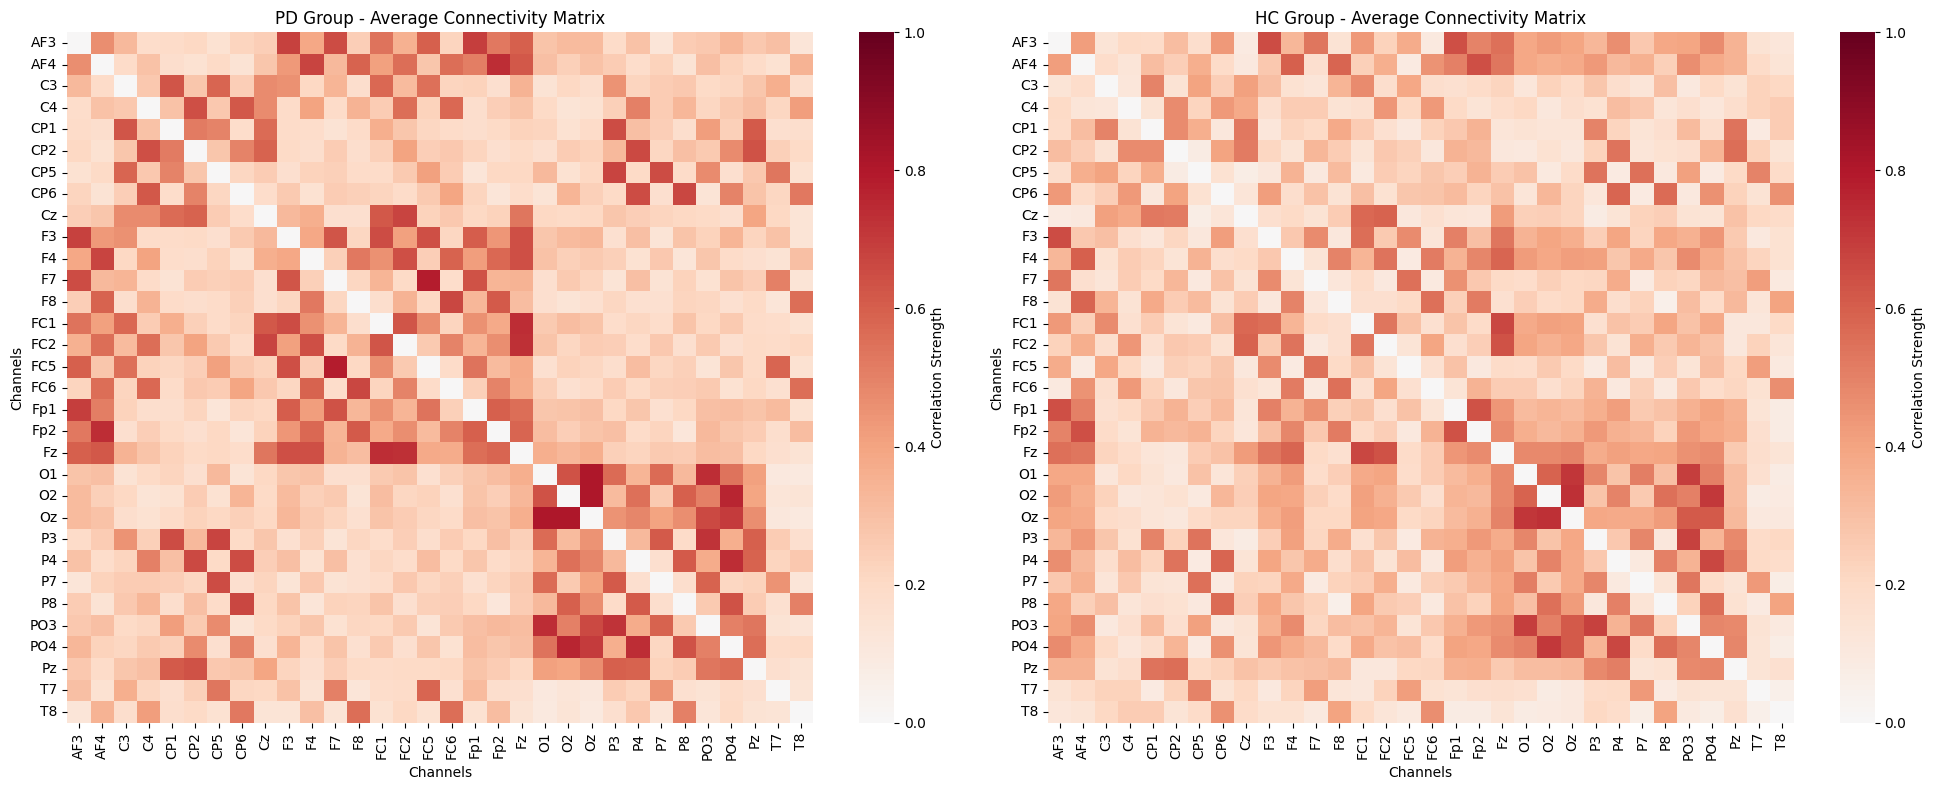

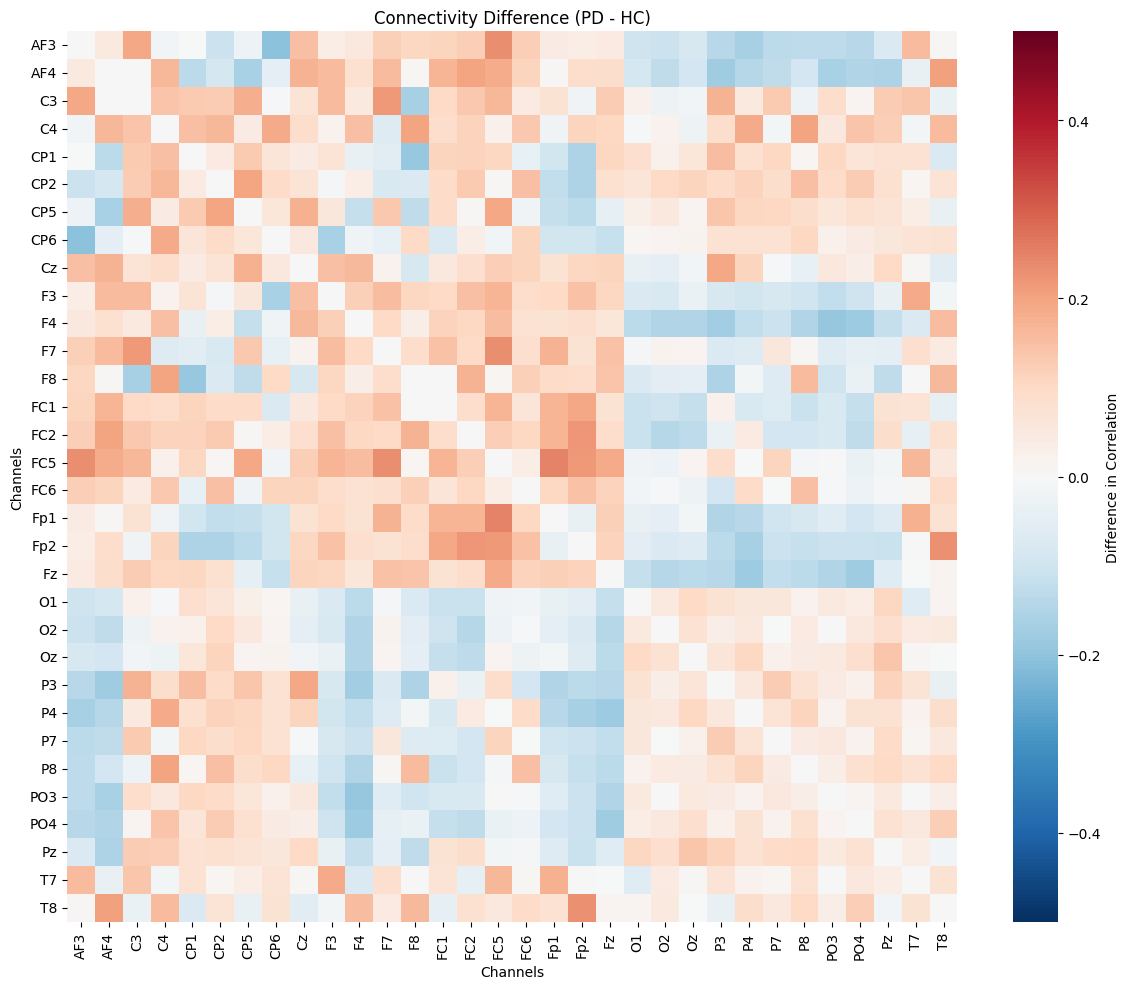

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create average connectivity matrices for PD and HC groups
def create_group_connectivity_matrix(graph_list, channel_order):
    n_channels = len(channel_order)
    avg_matrix = np.zeros((n_channels, n_channels))
    count_matrix = np.zeros((n_channels, n_channels))
    
    for graph in graph_list:
        for i, ch1 in enumerate(channel_order):
            for j, ch2 in enumerate(channel_order):
                if graph.has_edge(ch1, ch2):
                    avg_matrix[i, j] += graph[ch1][ch2]['weight']
                    count_matrix[i, j] += 1
    
    # Avoid division by zero
    count_matrix[count_matrix == 0] = 1
    avg_matrix = avg_matrix / count_matrix
    return avg_matrix

# Create average matrices for both groups
channel_order = channel  # Your channel list
pd_matrix = create_group_connectivity_matrix(graph_pd, channel_order)
hc_matrix = create_group_connectivity_matrix(graph_hc, channel_order)

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PD group heatmap
sns.heatmap(pd_matrix, ax=axes[0], cmap='RdBu_r', center=0,
            xticklabels=channel_order, yticklabels=channel_order,
            vmin=0, vmax=1, cbar_kws={'label': 'Correlation Strength'})
axes[0].set_title('PD Group - Average Connectivity Matrix')
axes[0].set_xlabel('Channels')
axes[0].set_ylabel('Channels')

# HC group heatmap
sns.heatmap(hc_matrix, ax=axes[1], cmap='RdBu_r', center=0,
            xticklabels=channel_order, yticklabels=channel_order,
            vmin=0, vmax=1, cbar_kws={'label': 'Correlation Strength'})
axes[1].set_title('HC Group - Average Connectivity Matrix')
axes[1].set_xlabel('Channels')
axes[1].set_ylabel('Channels')

plt.tight_layout()
plt.show()

# Difference heatmap (PD - HC)
diff_matrix = pd_matrix - hc_matrix
plt.figure(figsize=(12, 10))
sns.heatmap(diff_matrix, cmap='RdBu_r', center=0,
            xticklabels=channel_order, yticklabels=channel_order,
            vmin=-0.5, vmax=0.5, cbar_kws={'label': 'Difference in Correlation'})
plt.title('Connectivity Difference (PD - HC)')
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.tight_layout()
plt.show()

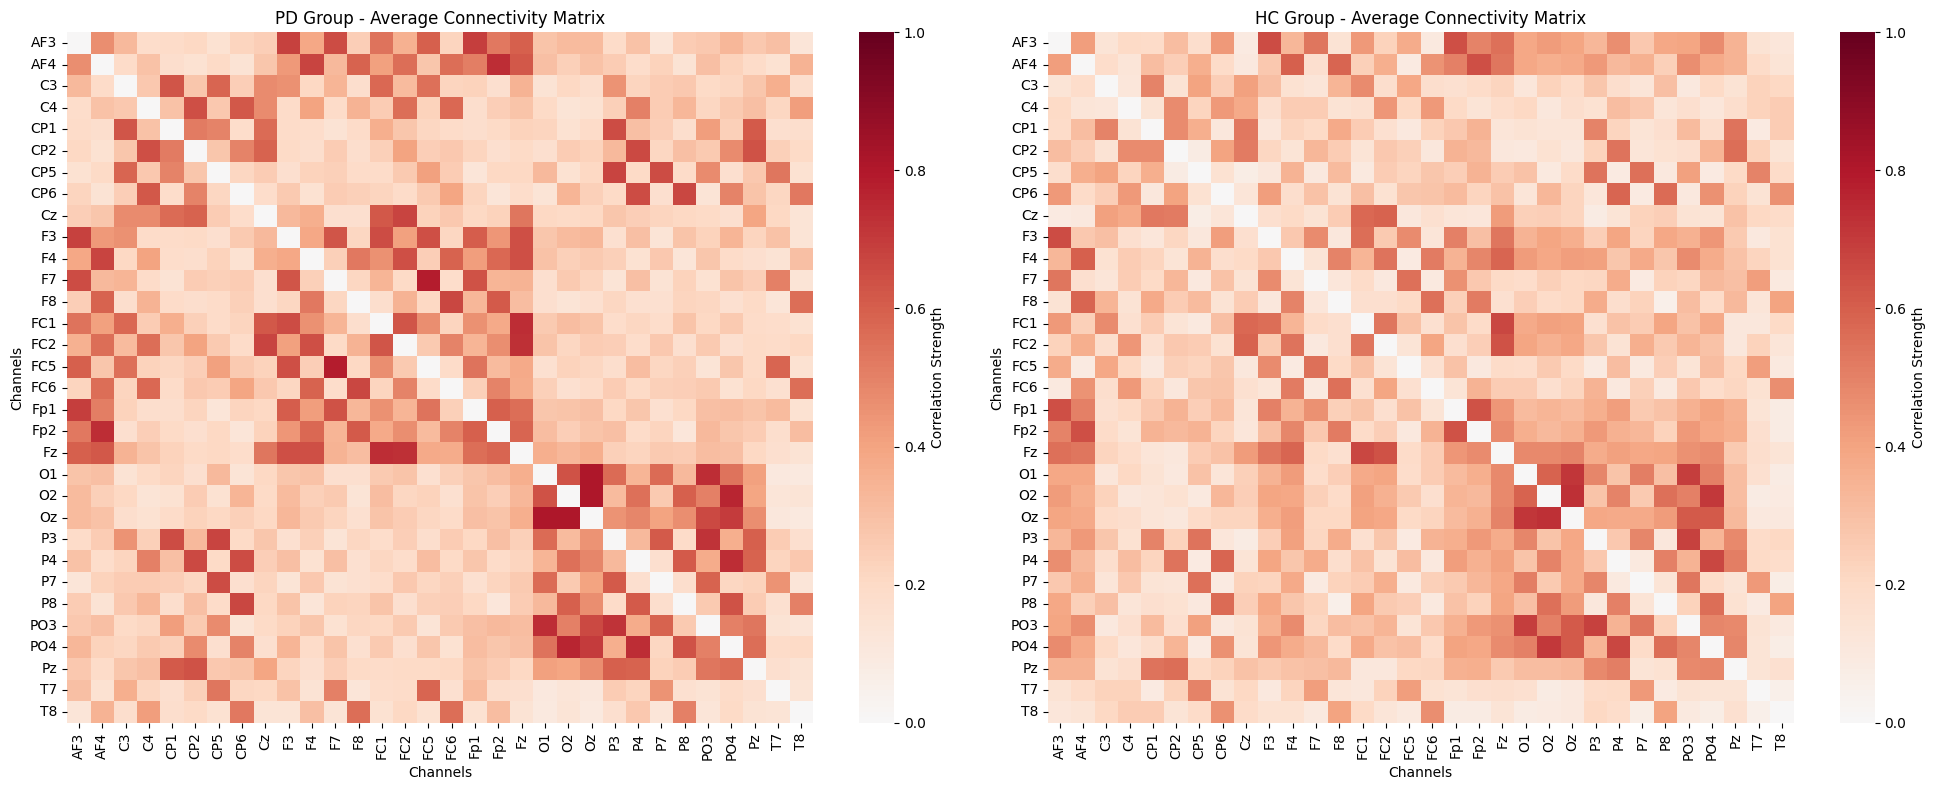

In [8]:
# Create average connectivity matrices for PD and HC groups
def create_group_connectivity_matrix(graph_list, channel_order):
    n_channels = len(channel_order)
    avg_matrix = np.zeros((n_channels, n_channels))
    count_matrix = np.zeros((n_channels, n_channels))
    
    for graph in graph_list:
        for i, ch1 in enumerate(channel_order):
            for j, ch2 in enumerate(channel_order):
                if graph.has_edge(ch1, ch2):
                    avg_matrix[i, j] += graph[ch1][ch2]['weight']
                    count_matrix[i, j] += 1
    
    # Avoid division by zero
    count_matrix[count_matrix == 0] = 1
    avg_matrix = avg_matrix / count_matrix
    return avg_matrix

# Create average matrices for both groups
channel_order = channel  # Your channel list
pd_matrix = create_group_connectivity_matrix(graph_pd, channel_order)
hc_matrix = create_group_connectivity_matrix(graph_hc, channel_order)

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PD group heatmap
sns.heatmap(pd_matrix, ax=axes[0], cmap='RdBu_r', center=0,
            xticklabels=channel_order, yticklabels=channel_order,
            vmin=0, vmax=1, cbar_kws={'label': 'Correlation Strength'})
axes[0].set_title('PD Group - Average Connectivity Matrix')
axes[0].set_xlabel('Channels')
axes[0].set_ylabel('Channels')

# HC group heatmap
sns.heatmap(hc_matrix, ax=axes[1], cmap='RdBu_r', center=0,
            xticklabels=channel_order, yticklabels=channel_order,
            vmin=0, vmax=1, cbar_kws={'label': 'Correlation Strength'})
axes[1].set_title('HC Group - Average Connectivity Matrix')
axes[1].set_xlabel('Channels')
axes[1].set_ylabel('Channels')

plt.tight_layout()
plt.show()

## Pearson

In [ ]:
# Create average connectivity matrices for PD and HC groups
def create_group_connectivity_matrix(graph_list, channel_order):
    n_channels = len(channel_order)
    avg_matrix = np.zeros((n_channels, n_channels))
    count_matrix = np.zeros((n_channels, n_channels))
    
    for graph in graph_list:
        for i, ch1 in enumerate(channel_order):
            for j, ch2 in enumerate(channel_order):
                if graph.has_edge(ch1, ch2):
                    avg_matrix[i, j] += graph[ch1][ch2]['weight']
                    count_matrix[i, j] += 1
    
    # Avoid division by zero
    count_matrix[count_matrix == 0] = 1
    avg_matrix = avg_matrix / count_matrix
    return avg_matrix

# Create average matrices for both groups
channel_order = channel  # Your channel list
pd_matrix = create_group_connectivity_matrix(graph_pd, channel_order)
hc_matrix = create_group_connectivity_matrix(graph_hc, channel_order)

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PD group heatmap
sns.heatmap(pd_matrix, ax=axes[0], cmap='RdBu_r', center=0,
            xticklabels=channel_order, yticklabels=channel_order,
            vmin=0, vmax=1, cbar_kws={'label': 'Correlation Strength'})
axes[0].set_title('PD Group - Average Connectivity Matrix')
axes[0].set_xlabel('Channels')
axes[0].set_ylabel('Channels')

# HC group heatmap
sns.heatmap(hc_matrix, ax=axes[1], cmap='RdBu_r', center=0,
            xticklabels=channel_order, yticklabels=channel_order,
            vmin=0, vmax=1, cbar_kws={'label': 'Correlation Strength'})
axes[1].set_title('HC Group - Average Connectivity Matrix')
axes[1].set_xlabel('Channels')
axes[1].set_ylabel('Channels')

plt.tight_layout()
plt.show()

# Difference heatmap (PD - HC)
diff_matrix = pd_matrix - hc_matrix
plt.figure(figsize=(12, 10))
sns.heatmap(diff_matrix, cmap='RdBu_r', center=0,
            xticklabels=channel_order, yticklabels=channel_order,
            vmin=-0.5, vmax=0.5, cbar_kws={'label': 'Difference in Correlation'})
plt.title('Connectivity Difference (PD - HC)')
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.tight_layout()
plt.show()

In [13]:
#%% complex network

df_dg=pd.DataFrame(columns=[ch_ft_degree])
df_dg.insert(0,'Subject','')
df_dg.insert(1,'Label','')

df_cl=pd.DataFrame(columns=[ch_ft_cl])
df_cl.insert(0,'Subject','')
df_cl.insert(1,'Label','')

df_bt=pd.DataFrame(columns=[ch_ft_betw])
df_bt.insert(0,'Subject','')
df_bt.insert(1,'Label','')

df_egv=pd.DataFrame(columns=[ch_ft_eig])
df_egv.insert(0,'Subject','')
df_egv.insert(1,'Label','')

df_inf_cent=pd.DataFrame(columns=[ch_ft_info])
df_inf_cent.insert(0,'Subject','')
df_inf_cent.insert(1,'Label','')

df_close=pd.DataFrame(columns=[ch_ft_close])
df_close.insert(0,'Subject','')
df_close.insert(1,'Label','')

df_ecc=pd.DataFrame(columns=[ch_ft_ecc])
df_ecc.insert(0,'Subject','')
df_ecc.insert(1,'Label','')


#Dataframe for edge betweennes
df_edge_btw=pd.DataFrame()

#%%
#list necessary for plotting graph
graph_pd=[]
graph_hc=[]
for sub in sub_list:
    df_eeg_subject=df_eeg_sub.loc[[sub]]#dataframe per subject
   
    df=pd.DataFrame(index=channel,columns=range(len(df_eeg_subject['Fp1'].values)))
    
    for ch in channel:
        df.loc[[ch]]=df_eeg_subject[ch].values
    
#    print(df)
#     #complex network
    df_nodes=pd.DataFrame(columns=['Id'],dtype=object)#empty dataframe for nodes
    
    for ch in channel:
        df_nodes=df_nodes.append({'Id':ch},ignore_index=True)
    print(df_nodes)
    
#     #Network with Pearson correlation
#     #source=first node
#     #target=note to be correlated
#     #Weight=pearson coefficient
    df_links_pearson=pd.DataFrame(columns=['Source','Target','Weight','p-value'],dtype=object)
    
    for ch1, index_ch1 in zip(channel,range(len(channel))):        
        indicators1 = df.loc[ch1].values.astype(float)
        for ch2 in channel[:index_ch1]:#tutti i canali tranne se stesso
            indicators2 = df.loc[ch2].values.astype(float)
            # nans = np.where(np.logical_or(np.isnan(indicators1),np.isnan(indicators2)))
            # indicators1_without_common_nans = [indicators1[i] for i in range(len(indicators1)) if np.isin(i,nans)==False]
            # indicators2_without_common_nans = [indicators2[i] for i in range(len(indicators2)) if np.isin(i,nans)==False]
            # # calculate Pearson's correlation
            # print('sub ',sub,' ch1 ',ch1,' indicator 1 ',len(indicators1_without_common_nans))
            # print('sub ',sub,' ch2 ',ch2,' indicator 2 ',len(indicators2_without_common_nans))           
            # if (len(indicators1_without_common_nans)!=0 or len(indicators2_without_common_nans)!=0):
            #     cor_coef, p = pearsonr(indicators1_without_common_nans, indicators2_without_common_nans)            
            #     #print('Channel: ',ch1,' and ',ch2,' -- Pearson\'s correlation coefficient: %.3f' % cor_coef)
            #     alpha = 10**(-2)
                
            #     if p > alpha: # alpha is the significance threshold
            #         print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
            #     else:
            #         print('Samples are correlated (reject H0) p=%.3f' % p)
            #         df_links_pearson = df_links_pearson.append({'Source': ch1, 'Target': ch2, 'Weight': np.absolute(cor_coef), 'p-value': p}, ignore_index=True)        
                    
                
            # else:
            #     df_links_pearson = df_links_pearson.append({'Source': ch1, 'Target': ch2, 'Weight': np.nan, 'p-value': np.nan}, ignore_index=True)                
    
            cor_coef, p = pearsonr(indicators1, indicators2)            
            
            alpha = 10**(-2)
            
            if p > alpha: # alpha is the significance threshold
                print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
            else:
                print('Samples are correlated (reject H0) p=%.3f' % p)
                df_links_pearson = df_links_pearson.append({'Source': ch1, 'Target': ch2, 'Weight': np.absolute(cor_coef), 'p-value': p}, ignore_index=True)        

    print(df_links_pearson)
       
    UN_net = nx.Graph() #for of subject
    UN_net.add_nodes_from(df_nodes['Id'])
    
    
    df_links = pd.DataFrame(columns = ['source','target','weight'], dtype=object)
    df_links['source'] = df_links_pearson['Source']
    df_links['target'] = df_links_pearson['Target']
    df_links['weight'] = df_links_pearson['Weight']
    df_links=df_links.dropna()
    UN_net = nx.from_pandas_edgelist(df_links, edge_attr = True)

    if sub.startswith('pd'):
        graph_pd.append(UN_net)
    if sub.startswith('hc'):
        graph_hc.append(UN_net)
        
#dictionary for degree
    dict_degree=dict(dict(UN_net.degree(weight='weight')))
    dict_keys_list = list(dict_degree.keys())
    dict_keys_list.sort()
    set1=set(channel)
    set2=set(dict_keys_list)
    missing=list(sorted(set1-set2))
    for i in range(len(missing)):
        dict_degree[missing[i]]='NaN'
  
    dict_keys_list=list(dict_degree.keys())
    dict_keys_list.sort()
    dict_degree = {i: dict_degree[i] for i in dict_keys_list}   
    degree=list(dict_degree.values())
    
#dictionary for betweennes
    dict_btw=dict(dict(nx.betweenness_centrality(UN_net,weight='weight')))
    dict_keys_list_btw = list(dict_btw.keys())
    dict_keys_list_btw.sort()
    set1_btw=set(channel)
    set2_btw=set(dict_keys_list_btw)
    missing_btw=list(sorted(set1_btw-set2_btw))
    for i in range(len(missing_btw)):
        dict_btw[missing_btw[i]]='NaN'
  
    dict_keys_list_btw=list(dict_btw.keys())
    dict_keys_list_btw.sort()
    dict_btw = {i: dict_btw[i] for i in dict_keys_list_btw}   
    betweenness_centrality=list(dict_btw.values())
   
#dictionary for clustering
    dict_clt=dict(dict(nx.clustering(UN_net,weight='weight')))
    dict_keys_list_clt = list(dict_clt.keys())
    dict_keys_list_clt.sort()
    set1_clt=set(channel)
    set2_clt=set(dict_keys_list_clt)
    missing_clt=list(sorted(set1_clt-set2_clt))
    for i in range(len(missing_clt)):
        dict_clt[missing_clt[i]]='NaN'
  
    dict_keys_list_clt=list(dict_clt.keys())
    dict_keys_list_clt.sort()
    dict_clt = {i: dict_clt[i] for i in dict_keys_list_clt}   
    coeff_clustering=list(dict_clt.values())
        
#dictionary for eigenvector_centrality
    dict_egv=dict(dict(nx.eigenvector_centrality(UN_net,weight='weight')))
    dict_keys_list_egv = list(dict_egv.keys())
    dict_keys_list_egv.sort()
    set1_egv=set(channel)
    set2_egv=set(dict_keys_list_egv)
    missing_egv=list(sorted(set1_egv-set2_egv))
    for i in range(len(missing_egv)):
        dict_egv[missing_egv[i]]='NaN'
  
    dict_keys_list_egv=list(dict_egv.keys())
    dict_keys_list_egv.sort()
    dict_egv = {i: dict_egv[i] for i in dict_keys_list_egv}   
    eigenvector_centrality=list(dict_egv.values())

    
# #dictionary for information centrality 

    dict_info=dict(dict(nx.information_centrality(UN_net,weight='weight')))
    dict_keys_list_info = list(dict_info.keys())
    dict_keys_list_info.sort()
    set1_info=set(channel)
    set2_info=set(dict_keys_list_info)
    missing_info=list(sorted(set1_info-set2_info))
    for i in range(len(missing_info)):
        dict_info[missing_info[i]]='NaN'

    dict_keys_list_info=list(dict_info.keys())
    dict_keys_list_info.sort()
    dict_info = {i: dict_info[i] for i in dict_keys_list_info}   
    info_centrality=list(dict_info.values())
    

#dictionary for communicability

    dict_close=nx.closeness_centrality(UN_net)
    dict_keys_list_close = list(dict_close.keys())
    dict_keys_list_close.sort()
    set1_close=set(channel)
    set2_close=set(dict_keys_list_close)
    missing_comm=list(sorted(set1_close-set2_close))
    for i in range(len(missing_comm)):
        dict_close[missing_comm[i]]='NaN'

    dict_keys_list_close=list(dict_close.keys())
    dict_keys_list_close.sort()
    dict_close = {i: dict_close[i] for i in dict_keys_list_close}   
    closeness=list(dict_close.values())


#dictionary for eccentricity

    dict_ecc=dict(dict(nx.eccentricity(UN_net)))
    dict_keys_list_ecc = list(dict_ecc.keys())
    dict_keys_list_ecc.sort()
    set1_ecc=set(channel)
    set2_ecc=set(dict_keys_list_ecc)
    missing_ecc=list(sorted(set1_ecc-set2_ecc))
    for i in range(len(missing_ecc)):
        dict_ecc[missing_ecc[i]]='NaN'

    dict_keys_list_ecc=list(dict_ecc.keys())
    dict_keys_list_ecc.sort()
    dict_ecc = {i: dict_ecc[i] for i in dict_keys_list_ecc}   
    eccentricity=list(dict_ecc.values())

#dataframe for edge betweenness centrality
    
    # edg_bt_series=pd.Series(dict(
    #         betweenness = nx.edge_betweenness_centrality(UN_net,weight='weight')
    #     ))
    # df_edg_btw=pd.DataFrame(dict(
    #         betweenness = nx.edge_betweenness_centrality(UN_net,weight='weight')
    #     )).T
    # df_edg_btw.append(df_edg_btw)
    # df = pd.DataFrame.from_dict(dict(
    #         betweenness = nx.edge_betweenness_centrality(UN_net,weight='weight')
    #     ), orient = 'index')
    df_edge_btw=df_edge_btw.append(pd.DataFrame.from_dict(dict(
            betweenness = nx.edge_betweenness_centrality(UN_net,weight='weight')
        ), orient = 'index'))
    print('sub' , sub)
    # df1.columns = ['_'.join(col) for col in df1.columns.values]
    # #df_edg_btw.columns = ['Egde_btw_'+col for col in df_edg_btw.columns.values]
    df_edge_btw= df_edge_btw.reset_index(drop=True)
    # df1['Subject']=sub
    # df1.insert(1,'Label',df_eeg_subject.Label.values[0])


    

    flat_degree=[]
    flat_degree.append(sub)
    flat_degree.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(degree)):
        flat_degree.append(degree[i])
        
    flat_betwennes=[]
    flat_betwennes.append(sub)
    flat_betwennes.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(betweenness_centrality)):
        flat_betwennes.append(betweenness_centrality[i])
  
    flat_clustering=[]
    flat_clustering.append(sub)
    flat_clustering.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(coeff_clustering)):
        flat_clustering.append(coeff_clustering[i])

    flat_eigenvector=[]
    flat_eigenvector.append(sub)
    flat_eigenvector.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(eigenvector_centrality)):
        flat_eigenvector.append(eigenvector_centrality[i])
        
    flat_info=[]
    flat_info.append(sub)
    flat_info.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(info_centrality)):
        flat_info.append(info_centrality[i])
        
         
    flat_close=[]
    flat_close.append(sub)
    flat_close.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(closeness)):
        flat_close.append(closeness[i])       
                        
    flat_ecc=[]
    flat_ecc.append(sub)
    flat_ecc.append(df_eeg_subject.Label.values[0])
    for i in range(0,len(eccentricity)):
        flat_ecc.append(eccentricity[i])        
    
        
    df_dg=df_dg.append(pd.DataFrame(np.array(flat_degree).reshape(1,-1),columns=list(df_dg.columns)),ignore_index=True)
    df_cl=df_cl.append(pd.DataFrame(np.array(flat_clustering).reshape(1,-1),columns=list(df_cl.columns)),ignore_index=True)
    df_bt=df_bt.append(pd.DataFrame(np.array(flat_betwennes).reshape(1,-1),columns=list(df_bt.columns)),ignore_index=True)
    df_egv=df_egv.append(pd.DataFrame(np.array(flat_eigenvector).reshape(1,-1),columns=list(df_egv.columns)),ignore_index=True)
 
    df_inf_cent=df_inf_cent.append(pd.DataFrame(np.array(flat_info).reshape(1,-1),columns=list(df_inf_cent.columns)),ignore_index=True)
    df_close=df_close.append(pd.DataFrame(np.array(flat_close).reshape(1,-1),columns=list(df_close.columns)),ignore_index=True)
    df_ecc=df_ecc.append(pd.DataFrame(np.array(flat_ecc).reshape(1,-1),columns=list(df_ecc.columns)),ignore_index=True)
    
    
# df_edge_btw=df_edge_btw.insert(0,'Subject',sub_list)
# df_edge_btw=df_edge_btw.insert(1,'Label',sub_label)
df_edge_btw.columns = ['_'.join(col) for col in df_edge_btw.columns.values]
df_edge_btw.insert(0,'Subject',sub_list)
#%% store features of degree in a csv file
df_dg.columns = df_dg.columns.get_level_values(0)
df_cl.columns = df_cl.columns.get_level_values(0)
df_bt.columns = df_bt.columns.get_level_values(0)
df_inf_cent.columns = df_inf_cent.columns.get_level_values(0)
df_egv.columns = df_egv.columns.get_level_values(0)
df_close.columns = df_close.columns.get_level_values(0)
#df_ecc.columns = df_ecc.columns.get_level_values(0)

extracted_col_cl=df_cl.iloc[:,2:]
extracted_col_bt=df_bt.iloc[:,2:]
extracted_col_egv=df_egv.iloc[:,2:]
extracted_col_info=df_inf_cent.iloc[:,2:]
extracted_col_close=df_close.iloc[:,2:]
#extracted_col_ecc=df_ecc.iloc[:,2:]
extracted_col_edge_btw=df_edge_btw.iloc[:,1:]


connectome_feat=df_dg.join(extracted_col_cl)
connectome_feat=connectome_feat.join(extracted_col_bt)
connectome_feat=connectome_feat.join(extracted_col_egv)
connectome_feat=connectome_feat.join(extracted_col_info)
connectome_feat=connectome_feat.join(extracted_col_close)
connectome_feat=connectome_feat.join(extracted_col_edge_btw)

connectome_feat.to_csv('/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/Phd/EEG/connectome_all_frequencies_metrica_pearson.csv')

/var/folders/1c/6rw74w9x2vx57lwg6hlnnlw80000gn/T/ipykernel_70146/4123862497.py:52: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_nodes=df_nodes.append({'Id':ch},ignore_index=True)
/var/folders/1c/6rw74w9x2vx57lwg6hlnnlw80000gn/T/ipykernel_70146/4123862497.py:52: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_nodes=df_nodes.append({'Id':ch},ignore_index=True)
/var/folders/1c/6rw74w9x2vx57lwg6hlnnlw80000gn/T/ipykernel_70146/4123862497.py:52: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_nodes=df_nodes.append({'Id':ch},ignore_index=True)
/var/folders/1c/6rw74w9x2vx57lwg6hlnnlw80000gn/T/ipykernel_70146/4123862497.py:52: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future vers

     Id
0   AF3
1   AF4
2    C3
3    C4
4   CP1
5   CP2
6   CP5
7   CP6
8    Cz
9    F3
10   F4
11   F7
12   F8
13  FC1
14  FC2
15  FC5
16  FC6
17  Fp1
18  Fp2
19   Fz
20   O1
21   O2
22   Oz
23   P3
24   P4
25   P7
26   P8
27  PO3
28  PO4
29   Pz
30   T7
31   T8
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are correlated (reject H0) p=0.000
Samples are uncorrelated (fail to reject H0) p=0.507
Samples are correlated (reject H0) p=0

ValueError: array must not contain infs or NaNs

### wPLI con libreria mne_connectivity

In [25]:
# ============================================================
# PARAMETRI
# ============================================================

# Frequenza di campionamento
sfreq = 511.0

# Intervallo di frequenza broadband
fmin = 0.5
fmax = 100.0

# Durata delle epoche.
# Con fmin = 0.5 Hz servono almeno 10 secondi
# per contenere almeno 5 cicli.
epoch_duration = 10.0

# Sovrapposizione del 50%
epoch_overlap = 5.0

# Densità del grafo:
# viene mantenuto il 70% delle connessioni più forti
graph_density = 0.70

# Un canale viene escluso dalla rete del singolo soggetto
# quando più del 20% dei suoi campioni è NaN o infinito.
max_channel_missing_fraction = 0.20

# Numero minimo di canali validi richiesti
minimum_valid_channels = 4

# Numero minimo consigliato di epoche
minimum_number_epochs = 5

# Costante per evitare divisioni per zero
epsilon = 1e-12


# ============================================================
# PERCORSI DI OUTPUT
# ============================================================

output_directory = (
    "/Users/donato/Library/CloudStorage/"
    "OneDrive-IstitutoNazionalediFisicaNucleare/"
    "Phd/EEG"
)

os.makedirs(
    output_directory,
    exist_ok=True
)

connectome_output_path = os.path.join(
    output_directory,
    "connectome_0.5_100Hz_mne_wPLI_individual_channels_density_070.csv"
)

channel_diagnostics_output_path = os.path.join(
    output_directory,
    "wPLI_channel_diagnostics.csv"
)

subject_summary_output_path = os.path.join(
    output_directory,
    "wPLI_subject_summary.csv"
)

edge_weights_output_path = os.path.join(
    output_directory,
    "wPLI_retained_edges.csv"
)


# ============================================================
# CONTROLLO DEI PARAMETRI
# ============================================================

nyquist_frequency = sfreq / 2.0

if fmin <= 0:
    raise ValueError(
        "fmin deve essere maggiore di zero."
    )

if fmax >= nyquist_frequency:
    raise ValueError(
        f"fmax={fmax} Hz deve essere inferiore alla "
        f"frequenza di Nyquist, pari a "
        f"{nyquist_frequency:.2f} Hz."
    )

if fmin >= fmax:
    raise ValueError(
        "fmin deve essere inferiore a fmax."
    )

if not 0 < graph_density <= 1:
    raise ValueError(
        "graph_density deve essere compresa tra 0 e 1."
    )

if epoch_duration <= 0:
    raise ValueError(
        "epoch_duration deve essere maggiore di zero."
    )

if epoch_overlap < 0:
    raise ValueError(
        "epoch_overlap non può essere negativa."
    )

if epoch_overlap >= epoch_duration:
    raise ValueError(
        "epoch_overlap deve essere inferiore "
        "a epoch_duration."
    )

minimum_epoch_duration = 5.0 / fmin

if epoch_duration < minimum_epoch_duration:
    raise ValueError(
        f"Con fmin={fmin} Hz servono epoche di almeno "
        f"{minimum_epoch_duration:.2f} secondi."
    )


# ============================================================
# CONTROLLO DELLE VARIABILI DI INPUT
# ============================================================

if not isinstance(df_eeg_sub, pd.DataFrame):
    raise TypeError(
        "df_eeg_sub deve essere un pandas DataFrame."
    )

if len(sub_list) == 0:
    raise ValueError(
        "sub_list è vuota."
    )

if len(channel) == 0:
    raise ValueError(
        "La lista channel è vuota."
    )

missing_channel_columns = [
    ch
    for ch in channel
    if ch not in df_eeg_sub.columns
]

if missing_channel_columns:
    raise ValueError(
        "I seguenti canali non sono presenti "
        f"in df_eeg_sub: {missing_channel_columns}"
    )

if "Label" not in df_eeg_sub.columns:
    raise ValueError(
        "La colonna 'Label' non è presente "
        "in df_eeg_sub."
    )


# ============================================================
# FUNZIONE: CONVERSIONE IN NUMERICO
# ============================================================

def convert_eeg_dataframe_to_numeric(
    df_subject,
    channel_names
):
    """
    Converte le colonne EEG in formato numerico.

    I valori non convertibili vengono sostituiti con NaN.
    Gestisce anche numeri con virgola decimale e parentesi.
    """

    df_numeric = df_subject[
        channel_names
    ].copy()

    for ch in channel_names:

        series = df_numeric[ch]

        if not pd.api.types.is_numeric_dtype(series):

            series = (
                series
                .astype("string")
                .str.strip()
                .str.replace(",", ".", regex=False)
                .str.replace("[", "", regex=False)
                .str.replace("]", "", regex=False)
                .str.replace("(", "", regex=False)
                .str.replace(")", "", regex=False)
                .str.replace("{", "", regex=False)
                .str.replace("}", "", regex=False)
            )

        df_numeric[ch] = pd.to_numeric(
            series,
            errors="coerce"
        )

    return df_numeric


# ============================================================
# FUNZIONE: SELEZIONE CANALI DEL SINGOLO SOGGETTO
# ============================================================

def select_subject_channels(
    subject_data,
    channel_names,
    max_missing_fraction=0.20
):
    """
    Seleziona i canali validi del singolo soggetto.

    Un canale viene escluso soltanto per quel soggetto
    quando la percentuale di NaN o infiniti supera
    max_missing_fraction.

    Parameters
    ----------
    subject_data : numpy.ndarray
        Matrice con forma n_channels x n_times.

    channel_names : list
        Lista completa dei canali.

    max_missing_fraction : float
        Frazione massima di valori mancanti ammessa.

    Returns
    -------
    valid_data : numpy.ndarray
        Dati dei soli canali validi.

    valid_channels : list
        Nomi dei canali validi.

    excluded_channels : list
        Nomi dei canali esclusi.

    channel_diagnostics : list
        Diagnostica per ciascun canale.
    """

    subject_data = np.asarray(
        subject_data,
        dtype=float
    )

    if subject_data.ndim != 2:
        raise ValueError(
            "subject_data deve avere forma "
            "n_channels x n_times."
        )

    if subject_data.shape[0] != len(channel_names):
        raise ValueError(
            "Il numero di righe di subject_data non "
            "corrisponde al numero di canali."
        )

    valid_indices = []
    valid_channels = []
    excluded_channels = []
    channel_diagnostics = []

    for channel_index, ch in enumerate(
        channel_names
    ):

        signal = subject_data[
            channel_index
        ]

        invalid_mask = ~np.isfinite(
            signal
        )

        n_samples = signal.size

        n_invalid = int(
            invalid_mask.sum()
        )

        n_valid = int(
            n_samples - n_invalid
        )

        missing_fraction = (
            n_invalid / n_samples
            if n_samples > 0
            else 1.0
        )

        excluded = (
            missing_fraction
            > max_missing_fraction
        )

        channel_diagnostics.append({
            "Channel": ch,
            "N_samples": n_samples,
            "N_valid": n_valid,
            "N_invalid": n_invalid,
            "Missing_fraction": missing_fraction,
            "Missing_percentage": (
                missing_fraction * 100
            ),
            "Excluded": excluded
        })

        if excluded:

            excluded_channels.append(
                ch
            )

        else:

            valid_indices.append(
                channel_index
            )

            valid_channels.append(
                ch
            )

    valid_data = subject_data[
        valid_indices,
        :
    ]

    return (
        valid_data,
        valid_channels,
        excluded_channels,
        channel_diagnostics
    )


# ============================================================
# FUNZIONE: INTERPOLAZIONE TEMPORALE
# ============================================================

def interpolate_valid_channels(
    subject_data,
    channel_names,
    subject_name
):
    """
    Interpola temporalmente i valori NaN o infiniti
    nei canali precedentemente considerati validi.

    I valori mancanti all'inizio o alla fine del segnale
    vengono sostituiti con il primo o ultimo valore valido,
    secondo il comportamento di np.interp.
    """

    subject_data = np.asarray(
        subject_data,
        dtype=float
    ).copy()

    if subject_data.ndim != 2:
        raise ValueError(
            "subject_data deve avere forma "
            "n_channels x n_times."
        )

    n_channels, n_times = subject_data.shape

    if n_channels != len(channel_names):
        raise ValueError(
            "Il numero di canali nei dati non coincide "
            "con channel_names."
        )

    sample_indices = np.arange(
        n_times
    )

    for channel_index, ch in enumerate(
        channel_names
    ):

        signal = subject_data[
            channel_index
        ].copy()

        valid_mask = np.isfinite(
            signal
        )

        n_valid = int(
            valid_mask.sum()
        )

        n_invalid = int(
            n_times - n_valid
        )

        if n_invalid == 0:
            continue

        if n_valid < 2:
            raise ValueError(
                f"Il canale {ch} del soggetto "
                f"{subject_name} contiene soltanto "
                f"{n_valid} valori validi."
            )

        subject_data[
            channel_index
        ] = np.interp(
            sample_indices,
            sample_indices[valid_mask],
            signal[valid_mask]
        )

    remaining_invalid = int(
        np.sum(
            ~np.isfinite(subject_data)
        )
    )

    if remaining_invalid > 0:
        raise ValueError(
            f"Dopo l'interpolazione il soggetto "
            f"{subject_name} contiene ancora "
            f"{remaining_invalid} valori non validi."
        )

    return subject_data


# ============================================================
# FUNZIONE: CREAZIONE DELLE EPOCHE
# ============================================================

def create_fixed_length_epochs(
    data,
    sfreq,
    duration=10.0,
    overlap=5.0
):
    """
    Divide il segnale continuo in epoche a durata fissa.

    Input
    -----
    data:
        n_channels x n_times

    Output
    ------
    epochs_data:
        n_epochs x n_channels x n_times_epoch
    """

    data = np.asarray(
        data,
        dtype=float
    )

    if data.ndim != 2:
        raise ValueError(
            "data deve avere forma "
            "n_channels x n_times."
        )

    epoch_samples = int(
        round(
            duration * sfreq
        )
    )

    overlap_samples = int(
        round(
            overlap * sfreq
        )
    )

    step_samples = (
        epoch_samples
        - overlap_samples
    )

    if epoch_samples <= 0:
        raise ValueError(
            "La durata dell'epoca produce "
            "un numero di campioni non valido."
        )

    if step_samples <= 0:
        raise ValueError(
            "Il passo tra le epoche deve essere positivo."
        )

    _, n_times = data.shape

    if n_times < epoch_samples:
        raise ValueError(
            f"Il segnale contiene {n_times} campioni, "
            f"ma un'epoca di {duration} secondi "
            f"richiede {epoch_samples} campioni."
        )

    epoch_list = []

    for start in range(
        0,
        n_times - epoch_samples + 1,
        step_samples
    ):

        stop = start + epoch_samples

        epoch = data[
            :,
            start:stop
        ]

        epoch_list.append(
            epoch
        )

    if len(epoch_list) == 0:
        raise ValueError(
            "Non è stata generata alcuna epoca."
        )

    epochs_data = np.stack(
        epoch_list,
        axis=0
    )

    return epochs_data


# ============================================================
# FUNZIONE: CALCOLO wPLI
# ============================================================

def compute_wpli_matrix(
    epochs_data,
    channel_names,
    sfreq,
    fmin,
    fmax
):
    """
    Calcola la matrice wPLI mediante mne-connectivity.
    """

    epochs_data = np.asarray(
        epochs_data,
        dtype=float
    )

    if epochs_data.ndim != 3:
        raise ValueError(
            "epochs_data deve avere forma "
            "n_epochs x n_channels x n_times."
        )

    if epochs_data.shape[1] != len(channel_names):
        raise ValueError(
            "Il numero di canali nelle epoche non "
            "coincide con channel_names."
        )

    if not np.all(
        np.isfinite(epochs_data)
    ):
        raise ValueError(
            "epochs_data contiene NaN o infiniti."
        )

    connectivity = spectral_connectivity_epochs(
        data=epochs_data,
        names=channel_names,
        method="wpli",
        mode="multitaper",
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        mt_adaptive=False,
        n_jobs=1,
        verbose=False
    )

    connectivity_data = connectivity.get_data(
        output="dense"
    )

    wpli_matrix = np.squeeze(
        connectivity_data
    )

    expected_shape = (
        len(channel_names),
        len(channel_names)
    )

    if wpli_matrix.shape != expected_shape:
        raise ValueError(
            f"La matrice wPLI ha forma "
            f"{wpli_matrix.shape}; era attesa "
            f"{expected_shape}."
        )

    # MNE può memorizzare i valori in un solo triangolo.
    # maximum rende la matrice simmetrica senza sommare
    # due eventuali valori.
    wpli_matrix = np.maximum(
        wpli_matrix,
        wpli_matrix.T
    )

    np.fill_diagonal(
        wpli_matrix,
        0.0
    )

    wpli_matrix = np.clip(
        wpli_matrix,
        0.0,
        1.0
    )

    if not np.all(
        np.isfinite(wpli_matrix)
    ):
        raise ValueError(
            "La matrice wPLI contiene NaN o infiniti."
        )

    return wpli_matrix


# ============================================================
# FUNZIONE: COSTRUZIONE DEL GRAFO
# ============================================================

def create_wpli_graph(
    wpli_matrix,
    channel_names,
    graph_density,
    epsilon=1e-12
):
    """
    Costruisce il grafo mantenendo una frazione fissa
    delle connessioni wPLI più forti.
    """

    wpli_matrix = np.asarray(
        wpli_matrix,
        dtype=float
    )

    n_channels = len(
        channel_names
    )

    expected_shape = (
        n_channels,
        n_channels
    )

    if wpli_matrix.shape != expected_shape:
        raise ValueError(
            f"La matrice wPLI deve avere forma "
            f"{expected_shape}."
        )

    edge_records = []

    for index_1 in range(
        n_channels
    ):

        for index_2 in range(
            index_1
        ):

            edge_records.append({
                "Source": channel_names[index_1],
                "Target": channel_names[index_2],
                "Weight": float(
                    wpli_matrix[
                        index_1,
                        index_2
                    ]
                )
            })

    df_links = pd.DataFrame(
        edge_records
    )

    df_links = (
        df_links
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna(
            subset=["Weight"]
        )
        .sort_values(
            "Weight",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    total_edges = len(
        df_links
    )

    if total_edges == 0:
        raise ValueError(
            "Non sono disponibili connessioni valide."
        )

    n_edges_to_keep = int(
        np.ceil(
            total_edges
            * graph_density
        )
    )

    n_edges_to_keep = max(
        1,
        min(
            n_edges_to_keep,
            total_edges
        )
    )

    selected_edges = (
        df_links
        .head(
            n_edges_to_keep
        )
        .copy()
    )

    graph = nx.from_pandas_edgelist(
        selected_edges,
        source="Source",
        target="Target",
        edge_attr="Weight",
        create_using=nx.Graph()
    )

    # Mantiene anche gli eventuali nodi isolati
    # appartenenti ai canali validi.
    graph.add_nodes_from(
        channel_names
    )

    # NetworkX userà:
    # Weight come forza della connessione;
    # distance per le metriche basate sui cammini.
    for (
        node_1,
        node_2,
        edge_data
    ) in graph.edges(data=True):

        weight = float(
            edge_data["Weight"]
        )

        edge_data["weight"] = weight

        edge_data["distance"] = (
            1.0
            / (
                weight
                + epsilon
            )
        )

    return (
        graph,
        selected_edges
    )


# ============================================================
# FUNZIONE: RIALLINEAMENTO DELLE METRICHE
# ============================================================

def align_metric_to_all_channels(
    metric_dictionary,
    all_channels
):
    """
    Restituisce una feature per ogni canale originale.

    Se un canale è stato escluso dalla rete del soggetto,
    la feature corrispondente viene impostata a np.nan.
    """

    return [
        metric_dictionary.get(
            ch,
            np.nan
        )
        for ch in all_channels
    ]


# ============================================================
# NOMI DELLE FEATURE
# ============================================================

degree_columns = [
    f"Degree_{ch}"
    for ch in channel
]

clustering_columns = [
    f"Clustering_{ch}"
    for ch in channel
]

betweenness_columns = [
    f"Betweenness_{ch}"
    for ch in channel
]

eigenvector_columns = [
    f"Eigenvector_{ch}"
    for ch in channel
]

information_columns = [
    f"Information_{ch}"
    for ch in channel
]

closeness_columns = [
    f"Closeness_{ch}"
    for ch in channel
]

eccentricity_columns = [
    f"Eccentricity_{ch}"
    for ch in channel
]


# ============================================================
# CONTENITORI DEI RISULTATI
# ============================================================

degree_records = []
clustering_records = []
betweenness_records = []
eigenvector_records = []
information_records = []
closeness_records = []
eccentricity_records = []

edge_betweenness_records = []

channel_diagnostic_records = []
subject_summary_records = []
retained_edge_records = []

graph_pd = []
graph_hc = []


# ============================================================
# CICLO PRINCIPALE SUI SOGGETTI
# ============================================================

for sub in sub_list:

    print("\n" + "=" * 80)
    print(f"ELABORAZIONE SOGGETTO: {sub}")
    print("=" * 80)

    # --------------------------------------------------------
    # CONTROLLO PRESENZA SOGGETTO
    # --------------------------------------------------------

    if sub not in df_eeg_sub.index:

        reason = (
            "Soggetto non presente nell'indice "
            "di df_eeg_sub."
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": np.nan,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": 0,
            "N_excluded_channels": len(channel),
            "Excluded_channels": "; ".join(channel),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # ESTRAZIONE DEL SOGGETTO
    # --------------------------------------------------------

    df_eeg_subject = df_eeg_sub.loc[
        [sub]
    ].copy()

    subject_label = df_eeg_subject[
        "Label"
    ].iloc[0]

    # --------------------------------------------------------
    # CONVERSIONE IN NUMERICO
    # --------------------------------------------------------

    df_numeric = convert_eeg_dataframe_to_numeric(
        df_subject=df_eeg_subject,
        channel_names=channel
    )

    # df_numeric:
    # n_samples x n_channels
    #
    # subject_data:
    # n_channels x n_samples
    subject_data = (
        df_numeric
        .to_numpy(
            dtype=float
        )
        .T
    )

    print(
        f"Dimensione dati continui: "
        f"{subject_data.shape}"
    )

    if subject_data.shape[1] == 0:

        reason = (
            "Il soggetto non contiene campioni EEG."
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": 0,
            "N_excluded_channels": len(channel),
            "Excluded_channels": "; ".join(channel),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # SELEZIONE INDIVIDUALE DEI CANALI
    # --------------------------------------------------------

    (
        valid_subject_data,
        valid_subject_channels,
        excluded_subject_channels,
        channel_diagnostics
    ) = select_subject_channels(
        subject_data=subject_data,
        channel_names=channel,
        max_missing_fraction=(
            max_channel_missing_fraction
        )
    )

    for diagnostic in channel_diagnostics:

        channel_diagnostic_records.append({
            "Subject": sub,
            "Label": subject_label,
            **diagnostic
        })

    print(
        f"Canali validi: "
        f"{len(valid_subject_channels)}/{len(channel)}"
    )

    print(
        f"Canali esclusi soltanto per {sub}: "
        f"{excluded_subject_channels}"
    )

    # --------------------------------------------------------
    # CONTROLLO NUMERO MINIMO DI CANALI
    # --------------------------------------------------------

    if (
        len(valid_subject_channels)
        < minimum_valid_channels
    ):

        reason = (
            "Numero insufficiente di canali validi: "
            f"{len(valid_subject_channels)}."
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # INTERPOLAZIONE TEMPORALE DEI NaN RESIDUI
    # --------------------------------------------------------

    try:

        valid_subject_data = interpolate_valid_channels(
            subject_data=valid_subject_data,
            channel_names=valid_subject_channels,
            subject_name=sub
        )

    except ValueError as error:

        reason = str(
            error
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # CREAZIONE DELLE EPOCHE
    # --------------------------------------------------------

    try:

        epochs_data = create_fixed_length_epochs(
            data=valid_subject_data,
            sfreq=sfreq,
            duration=epoch_duration,
            overlap=epoch_overlap
        )

    except ValueError as error:

        reason = str(
            error
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    number_epochs = epochs_data.shape[0]

    print(
        f"Dimensione dati epocati: "
        f"{epochs_data.shape}"
    )

    print(
        f"Numero di epoche: "
        f"{number_epochs}"
    )

    if number_epochs < minimum_number_epochs:

        warnings.warn(
            f"Il soggetto {sub} presenta soltanto "
            f"{number_epochs} epoche. La stima della "
            "wPLI potrebbe essere instabile.",
            RuntimeWarning
        )

    # --------------------------------------------------------
    # CALCOLO DELLA wPLI
    # --------------------------------------------------------

    try:

        wpli_matrix = compute_wpli_matrix(
            epochs_data=epochs_data,
            channel_names=valid_subject_channels,
            sfreq=sfreq,
            fmin=fmin,
            fmax=fmax
        )

    except Exception as error:

        reason = (
            "Errore nel calcolo della wPLI: "
            f"{error}"
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": number_epochs,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # COSTRUZIONE DELLA RETE
    # --------------------------------------------------------

    try:

        UN_net, selected_edges = create_wpli_graph(
            wpli_matrix=wpli_matrix,
            channel_names=valid_subject_channels,
            graph_density=graph_density,
            epsilon=epsilon
        )

    except Exception as error:

        reason = (
            "Errore nella costruzione del grafo: "
            f"{error}"
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": number_epochs,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    graph_connected = nx.is_connected(
        UN_net
    )

    print(
        f"Nodi della rete: "
        f"{UN_net.number_of_nodes()}"
    )

    print(
        f"Archi della rete: "
        f"{UN_net.number_of_edges()}"
    )

    print(
        f"Grafo connesso: "
        f"{graph_connected}"
    )

    print(
        f"wPLI minima mantenuta: "
        f"{selected_edges['Weight'].min():.6f}"
    )

    print(
        f"wPLI massima mantenuta: "
        f"{selected_edges['Weight'].max():.6f}"
    )

    # Salva gli archi mantenuti
    for _, edge_row in selected_edges.iterrows():

        retained_edge_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Source": edge_row["Source"],
            "Target": edge_row["Target"],
            "Weight": edge_row["Weight"],
            "N_valid_channels": (
                len(valid_subject_channels)
            )
        })

    # Mantiene l'organizzazione dei grafi per gruppo
    if str(sub).lower().startswith("pd"):

        graph_pd.append(
            UN_net.copy()
        )

    if str(sub).lower().startswith("hc"):

        graph_hc.append(
            UN_net.copy()
        )

    # --------------------------------------------------------
    # DEGREE PESATO
    # --------------------------------------------------------

    degree_dictionary = dict(
        UN_net.degree(
            weight="weight"
        )
    )

    degree_values = align_metric_to_all_channels(
        metric_dictionary=degree_dictionary,
        all_channels=channel
    )

    degree_records.append([
        sub,
        subject_label,
        *degree_values
    ])

    # --------------------------------------------------------
    # CLUSTERING PESATO
    # --------------------------------------------------------

    clustering_dictionary = nx.clustering(
        UN_net,
        weight="weight"
    )

    clustering_values = align_metric_to_all_channels(
        metric_dictionary=clustering_dictionary,
        all_channels=channel
    )

    clustering_records.append([
        sub,
        subject_label,
        *clustering_values
    ])

    # --------------------------------------------------------
    # BETWEENNESS CENTRALITY
    # --------------------------------------------------------

    betweenness_dictionary = (
        nx.betweenness_centrality(
            UN_net,
            weight="distance",
            normalized=True
        )
    )

    betweenness_values = align_metric_to_all_channels(
        metric_dictionary=betweenness_dictionary,
        all_channels=channel
    )

    betweenness_records.append([
        sub,
        subject_label,
        *betweenness_values
    ])

    # --------------------------------------------------------
    # EIGENVECTOR CENTRALITY
    # --------------------------------------------------------

    try:

        eigenvector_dictionary = (
            nx.eigenvector_centrality(
                UN_net,
                weight="weight",
                max_iter=5000,
                tol=1e-8
            )
        )

    except nx.PowerIterationFailedConvergence:

        warnings.warn(
            f"Eigenvector centrality non convergente "
            f"per il soggetto {sub}.",
            RuntimeWarning
        )

        eigenvector_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    except Exception as error:

        warnings.warn(
            f"Errore nel calcolo della eigenvector "
            f"centrality per {sub}: {error}",
            RuntimeWarning
        )

        eigenvector_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    eigenvector_values = align_metric_to_all_channels(
        metric_dictionary=eigenvector_dictionary,
        all_channels=channel
    )

    eigenvector_records.append([
        sub,
        subject_label,
        *eigenvector_values
    ])

    # --------------------------------------------------------
    # INFORMATION CENTRALITY
    # --------------------------------------------------------

    if graph_connected:

        try:

            information_dictionary = (
                nx.information_centrality(
                    UN_net,
                    weight="distance"
                )
            )

        except Exception as error:

            warnings.warn(
                f"Information centrality non calcolabile "
                f"per {sub}: {error}",
                RuntimeWarning
            )

            information_dictionary = {
                ch: np.nan
                for ch in valid_subject_channels
            }

    else:

        information_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    information_values = align_metric_to_all_channels(
        metric_dictionary=information_dictionary,
        all_channels=channel
    )

    information_records.append([
        sub,
        subject_label,
        *information_values
    ])

    # --------------------------------------------------------
    # CLOSENESS CENTRALITY
    # --------------------------------------------------------

    try:

        closeness_dictionary = (
            nx.closeness_centrality(
                UN_net,
                distance="distance",
                wf_improved=True
            )
        )

    except Exception as error:

        warnings.warn(
            f"Closeness centrality non calcolabile "
            f"per {sub}: {error}",
            RuntimeWarning
        )

        closeness_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    closeness_values = align_metric_to_all_channels(
        metric_dictionary=closeness_dictionary,
        all_channels=channel
    )

    closeness_records.append([
        sub,
        subject_label,
        *closeness_values
    ])

    # --------------------------------------------------------
    # ECCENTRICITY PESATA
    # --------------------------------------------------------

    if graph_connected:

        try:

            shortest_paths = dict(
                nx.all_pairs_dijkstra_path_length(
                    UN_net,
                    weight="distance"
                )
            )

            eccentricity_dictionary = nx.eccentricity(
                UN_net,
                sp=shortest_paths
            )

        except Exception as error:

            warnings.warn(
                f"Eccentricity non calcolabile "
                f"per {sub}: {error}",
                RuntimeWarning
            )

            eccentricity_dictionary = {
                ch: np.nan
                for ch in valid_subject_channels
            }

    else:

        eccentricity_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    eccentricity_values = align_metric_to_all_channels(
        metric_dictionary=eccentricity_dictionary,
        all_channels=channel
    )

    eccentricity_records.append([
        sub,
        subject_label,
        *eccentricity_values
    ])

    # --------------------------------------------------------
    # EDGE BETWEENNESS CENTRALITY
    # --------------------------------------------------------

    try:

        edge_betweenness_dictionary = (
            nx.edge_betweenness_centrality(
                UN_net,
                weight="distance",
                normalized=True
            )
        )

    except Exception as error:

        warnings.warn(
            f"Edge betweenness non calcolabile "
            f"per {sub}: {error}",
            RuntimeWarning
        )

        edge_betweenness_dictionary = {}

    edge_record = {
        "Subject": sub,
        "Label": subject_label
    }

    for edge, value in (
        edge_betweenness_dictionary.items()
    ):

        node_1, node_2 = sorted(
            edge
        )

        edge_name = (
            f"Edge_betweenness_"
            f"{node_1}_{node_2}"
        )

        edge_record[
            edge_name
        ] = value

    edge_betweenness_records.append(
        edge_record
    )

    # --------------------------------------------------------
    # RIEPILOGO DEL SOGGETTO
    # --------------------------------------------------------

    subject_summary_records.append({
        "Subject": sub,
        "Label": subject_label,
        "Included": True,
        "N_total_channels": len(channel),
        "N_valid_channels": (
            len(valid_subject_channels)
        ),
        "N_excluded_channels": (
            len(excluded_subject_channels)
        ),
        "Excluded_channels": "; ".join(
            excluded_subject_channels
        ),
        "N_epochs": number_epochs,
        "N_edges": (
            UN_net.number_of_edges()
        ),
        "Graph_connected": graph_connected,
        "Minimum_retained_wPLI": (
            selected_edges["Weight"].min()
        ),
        "Maximum_retained_wPLI": (
            selected_edges["Weight"].max()
        ),
        "Mean_retained_wPLI": (
            selected_edges["Weight"].mean()
        ),
        "Reason": ""
    })

    print(
        f"Soggetto {sub} completato."
    )


# ============================================================
# CONTROLLO DEI RISULTATI
# ============================================================

if len(degree_records) == 0:
    raise ValueError(
        "Nessun soggetto ha completato l'analisi."
    )


# ============================================================
# CREAZIONE DEI DATAFRAME DELLE METRICHE
# ============================================================

df_degree = pd.DataFrame(
    degree_records,
    columns=[
        "Subject",
        "Label",
        *degree_columns
    ]
)

df_clustering = pd.DataFrame(
    clustering_records,
    columns=[
        "Subject",
        "Label",
        *clustering_columns
    ]
)

df_betweenness = pd.DataFrame(
    betweenness_records,
    columns=[
        "Subject",
        "Label",
        *betweenness_columns
    ]
)

df_eigenvector = pd.DataFrame(
    eigenvector_records,
    columns=[
        "Subject",
        "Label",
        *eigenvector_columns
    ]
)

df_information = pd.DataFrame(
    information_records,
    columns=[
        "Subject",
        "Label",
        *information_columns
    ]
)

df_closeness = pd.DataFrame(
    closeness_records,
    columns=[
        "Subject",
        "Label",
        *closeness_columns
    ]
)

df_eccentricity = pd.DataFrame(
    eccentricity_records,
    columns=[
        "Subject",
        "Label",
        *eccentricity_columns
    ]
)

df_edge_betweenness = pd.DataFrame(
    edge_betweenness_records
)

df_channel_diagnostics = pd.DataFrame(
    channel_diagnostic_records
)

df_subject_summary = pd.DataFrame(
    subject_summary_records
)

df_retained_edges = pd.DataFrame(
    retained_edge_records
)


# ============================================================
# UNIONE DELLE FEATURE NODALI
# ============================================================

connectome_feat = df_degree.copy()

metric_dataframes = [
    df_clustering,
    df_betweenness,
    df_eigenvector,
    df_information,
    df_closeness,
    df_eccentricity
]

for metric_df in metric_dataframes:

    connectome_feat = connectome_feat.merge(
        metric_df.drop(
            columns=["Label"]
        ),
        on="Subject",
        how="left",
        validate="one_to_one"
    )


# ============================================================
# UNIONE DELLA EDGE BETWEENNESS
# ============================================================

if not df_edge_betweenness.empty:

    connectome_feat = connectome_feat.merge(
        df_edge_betweenness.drop(
            columns=["Label"]
        ),
        on="Subject",
        how="left",
        validate="one_to_one"
    )


# ============================================================
# CONVERSIONE DELLE FEATURE IN NUMERICO
# ============================================================

feature_columns = [
    column_name
    for column_name in connectome_feat.columns
    if column_name not in [
        "Subject",
        "Label"
    ]
]

connectome_feat[
    feature_columns
] = (
    connectome_feat[
        feature_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


# ============================================================
# ORDINAMENTO SECONDO sub_list
# ============================================================

subject_order = {
    subject: index
    for index, subject in enumerate(
        sub_list
    )
}

connectome_feat[
    "_subject_order"
] = (
    connectome_feat[
        "Subject"
    ]
    .map(
        subject_order
    )
)

connectome_feat = (
    connectome_feat
    .sort_values(
        "_subject_order"
    )
    .drop(
        columns=[
            "_subject_order"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# ESPORTAZIONE
# ============================================================

connectome_feat.to_csv(
    connectome_output_path,
    index=False
)

df_channel_diagnostics.to_csv(
    channel_diagnostics_output_path,
    index=False
)

df_subject_summary.to_csv(
    subject_summary_output_path,
    index=False
)

df_retained_edges.to_csv(
    edge_weights_output_path,
    index=False
)


# ============================================================
# RIEPILOGO FINALE
# ============================================================

included_subjects = df_subject_summary[
    df_subject_summary["Included"] == True
]

excluded_subjects = df_subject_summary[
    df_subject_summary["Included"] == False
]

print("\n" + "=" * 80)
print("ANALISI COMPLETATA")
print("=" * 80)

print(
    f"Canali originali: "
    f"{len(channel)}"
)

print(
    "Nessun canale è stato rimosso globalmente."
)

print(
    f"Soggetti iniziali: "
    f"{len(sub_list)}"
)

print(
    f"Soggetti inclusi: "
    f"{len(included_subjects)}"
)

print(
    f"Soggetti esclusi: "
    f"{len(excluded_subjects)}"
)

if not included_subjects.empty:

    print(
        "\nNumero di canali validi per soggetto incluso:"
    )

    print(
        included_subjects[
            [
                "Subject",
                "N_valid_channels",
                "N_excluded_channels",
                "Excluded_channels"
            ]
        ].to_string(
            index=False
        )
    )

if not excluded_subjects.empty:

    print(
        "\nSoggetti esclusi:"
    )

    print(
        excluded_subjects[
            [
                "Subject",
                "Reason"
            ]
        ].to_string(
            index=False
        )
    )

print(
    f"\nDimensioni dataframe finale: "
    f"{connectome_feat.shape}"
)

print(
    f"\nFeature salvate in:\n"
    f"{connectome_output_path}"
)

print(
    f"\nDiagnostica dei canali salvata in:\n"
    f"{channel_diagnostics_output_path}"
)

print(
    f"\nRiepilogo dei soggetti salvato in:\n"
    f"{subject_summary_output_path}"
)

print(
    f"\nArchi mantenuti salvati in:\n"
    f"{edge_weights_output_path}"
)


ELABORAZIONE SOGGETTO: hc1
Dimensione dati continui: (32, 64695)
Canali validi: 31/32
Canali esclusi soltanto per hc1: ['F3']
Dimensione dati epocati: (24, 31, 5110)
Numero di epoche: 24
Nodi della rete: 31
Archi della rete: 326
Grafo connesso: True
wPLI minima mantenuta: 0.301406
wPLI massima mantenuta: 0.753323
Soggetto hc1 completato.

ELABORAZIONE SOGGETTO: hc10
Dimensione dati continui: (32, 59365)
Canali validi: 28/32
Canali esclusi soltanto per hc10: ['CP6', 'F8', 'Pz', 'T8']
Dimensione dati epocati: (22, 28, 5110)
Numero di epoche: 22
Nodi della rete: 28
Archi della rete: 265
Grafo connesso: True
wPLI minima mantenuta: 0.334415
wPLI massima mantenuta: 0.766884
Soggetto hc10 completato.

ELABORAZIONE SOGGETTO: hc18
Dimensione dati continui: (32, 70136)
Canali validi: 30/32
Canali esclusi soltanto per hc18: ['F8', 'T8']
Dimensione dati epocati: (26, 30, 5110)
Numero di epoche: 26
Nodi della rete: 30
Archi della rete: 305
Grafo connesso: True
wPLI minima mantenuta: 0.295626
wPLI 

/var/folders/1c/6rw74w9x2vx57lwg6hlnnlw80000gn/T/ipykernel_60843/3912522264.py:1844: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  connectome_feat[


# plv

In [7]:
# ============================================================
# PARAMETRI
# ============================================================

# Frequenza di campionamento
sfreq = 511.0

# Intervallo di frequenza broadband
fmin = 0.5
fmax = 100.0

# Durata delle epoche.
# Con fmin = 0.5 Hz servono almeno 10 secondi
# per contenere almeno 5 cicli.
epoch_duration = 10.0

# Sovrapposizione del 50%
epoch_overlap = 5.0

# Densità del grafo:
# viene mantenuto il 70% delle connessioni più forti
graph_density = 0.70

# Un canale viene escluso dalla rete del singolo soggetto
# quando più del 20% dei suoi campioni è NaN o infinito.
max_channel_missing_fraction = 0.20

# Numero minimo di canali validi richiesti
minimum_valid_channels = 4

# Numero minimo consigliato di epoche
minimum_number_epochs = 5

# Costante per evitare divisioni per zero
epsilon = 1e-12


# ============================================================
# PERCORSI DI OUTPUT
# ============================================================

output_directory = (
    "/Users/donato/Library/CloudStorage/"
    "OneDrive-IstitutoNazionalediFisicaNucleare/"
    "Phd/EEG"
)

os.makedirs(
    output_directory,
    exist_ok=True
)

connectome_output_path = os.path.join(
    output_directory,
    "connectome_0.5_100Hz_mne_PLV_individual_channels_density_070.csv"
)

channel_diagnostics_output_path = os.path.join(
    output_directory,
    "PLV_channel_diagnostics.csv"
)

subject_summary_output_path = os.path.join(
    output_directory,
    "PLV_subject_summary.csv"
)

edge_weights_output_path = os.path.join(
    output_directory,
    "PLV_retained_edges.csv"
)


# ============================================================
# CONTROLLO DEI PARAMETRI
# ============================================================

nyquist_frequency = sfreq / 2.0

if fmin <= 0:
    raise ValueError(
        "fmin deve essere maggiore di zero."
    )

if fmax >= nyquist_frequency:
    raise ValueError(
        f"fmax={fmax} Hz deve essere inferiore alla "
        f"frequenza di Nyquist, pari a "
        f"{nyquist_frequency:.2f} Hz."
    )

if fmin >= fmax:
    raise ValueError(
        "fmin deve essere inferiore a fmax."
    )

if not 0 < graph_density <= 1:
    raise ValueError(
        "graph_density deve essere compresa tra 0 e 1."
    )

if epoch_duration <= 0:
    raise ValueError(
        "epoch_duration deve essere maggiore di zero."
    )

if epoch_overlap < 0:
    raise ValueError(
        "epoch_overlap non può essere negativa."
    )

if epoch_overlap >= epoch_duration:
    raise ValueError(
        "epoch_overlap deve essere inferiore "
        "a epoch_duration."
    )

minimum_epoch_duration = 5.0 / fmin

if epoch_duration < minimum_epoch_duration:
    raise ValueError(
        f"Con fmin={fmin} Hz servono epoche di almeno "
        f"{minimum_epoch_duration:.2f} secondi."
    )


# ============================================================
# CONTROLLO DELLE VARIABILI DI INPUT
# ============================================================

if not isinstance(df_eeg_sub, pd.DataFrame):
    raise TypeError(
        "df_eeg_sub deve essere un pandas DataFrame."
    )

if len(sub_list) == 0:
    raise ValueError(
        "sub_list è vuota."
    )

if len(channel) == 0:
    raise ValueError(
        "La lista channel è vuota."
    )

missing_channel_columns = [
    ch
    for ch in channel
    if ch not in df_eeg_sub.columns
]

if missing_channel_columns:
    raise ValueError(
        "I seguenti canali non sono presenti "
        f"in df_eeg_sub: {missing_channel_columns}"
    )

if "Label" not in df_eeg_sub.columns:
    raise ValueError(
        "La colonna 'Label' non è presente "
        "in df_eeg_sub."
    )


# ============================================================
# FUNZIONE: CONVERSIONE IN NUMERICO
# ============================================================

def convert_eeg_dataframe_to_numeric(
    df_subject,
    channel_names
):
    """
    Converte le colonne EEG in formato numerico.

    I valori non convertibili vengono sostituiti con NaN.
    Gestisce anche numeri con virgola decimale e parentesi.
    """

    df_numeric = df_subject[
        channel_names
    ].copy()

    for ch in channel_names:

        series = df_numeric[ch]

        if not pd.api.types.is_numeric_dtype(series):

            series = (
                series
                .astype("string")
                .str.strip()
                .str.replace(",", ".", regex=False)
                .str.replace("[", "", regex=False)
                .str.replace("]", "", regex=False)
                .str.replace("(", "", regex=False)
                .str.replace(")", "", regex=False)
                .str.replace("{", "", regex=False)
                .str.replace("}", "", regex=False)
            )

        df_numeric[ch] = pd.to_numeric(
            series,
            errors="coerce"
        )

    return df_numeric


# ============================================================
# FUNZIONE: SELEZIONE CANALI DEL SINGOLO SOGGETTO
# ============================================================

def select_subject_channels(
    subject_data,
    channel_names,
    max_missing_fraction=0.20
):
    """
    Seleziona i canali validi del singolo soggetto.

    Un canale viene escluso soltanto per quel soggetto
    quando la percentuale di NaN o infiniti supera
    max_missing_fraction.

    Parameters
    ----------
    subject_data : numpy.ndarray
        Matrice con forma n_channels x n_times.

    channel_names : list
        Lista completa dei canali.

    max_missing_fraction : float
        Frazione massima di valori mancanti ammessa.

    Returns
    -------
    valid_data : numpy.ndarray
        Dati dei soli canali validi.

    valid_channels : list
        Nomi dei canali validi.

    excluded_channels : list
        Nomi dei canali esclusi.

    channel_diagnostics : list
        Diagnostica per ciascun canale.
    """

    subject_data = np.asarray(
        subject_data,
        dtype=float
    )

    if subject_data.ndim != 2:
        raise ValueError(
            "subject_data deve avere forma "
            "n_channels x n_times."
        )

    if subject_data.shape[0] != len(channel_names):
        raise ValueError(
            "Il numero di righe di subject_data non "
            "corrisponde al numero di canali."
        )

    valid_indices = []
    valid_channels = []
    excluded_channels = []
    channel_diagnostics = []

    for channel_index, ch in enumerate(
        channel_names
    ):

        signal = subject_data[
            channel_index
        ]

        invalid_mask = ~np.isfinite(
            signal
        )

        n_samples = signal.size

        n_invalid = int(
            invalid_mask.sum()
        )

        n_valid = int(
            n_samples - n_invalid
        )

        missing_fraction = (
            n_invalid / n_samples
            if n_samples > 0
            else 1.0
        )

        excluded = (
            missing_fraction
            > max_missing_fraction
        )

        channel_diagnostics.append({
            "Channel": ch,
            "N_samples": n_samples,
            "N_valid": n_valid,
            "N_invalid": n_invalid,
            "Missing_fraction": missing_fraction,
            "Missing_percentage": (
                missing_fraction * 100
            ),
            "Excluded": excluded
        })

        if excluded:

            excluded_channels.append(
                ch
            )

        else:

            valid_indices.append(
                channel_index
            )

            valid_channels.append(
                ch
            )

    valid_data = subject_data[
        valid_indices,
        :
    ]

    return (
        valid_data,
        valid_channels,
        excluded_channels,
        channel_diagnostics
    )


# ============================================================
# FUNZIONE: INTERPOLAZIONE TEMPORALE
# ============================================================

def interpolate_valid_channels(
    subject_data,
    channel_names,
    subject_name
):
    """
    Interpola temporalmente i valori NaN o infiniti
    nei canali precedentemente considerati validi.

    I valori mancanti all'inizio o alla fine del segnale
    vengono sostituiti con il primo o ultimo valore valido,
    secondo il comportamento di np.interp.
    """

    subject_data = np.asarray(
        subject_data,
        dtype=float
    ).copy()

    if subject_data.ndim != 2:
        raise ValueError(
            "subject_data deve avere forma "
            "n_channels x n_times."
        )

    n_channels, n_times = subject_data.shape

    if n_channels != len(channel_names):
        raise ValueError(
            "Il numero di canali nei dati non coincide "
            "con channel_names."
        )

    sample_indices = np.arange(
        n_times
    )

    for channel_index, ch in enumerate(
        channel_names
    ):

        signal = subject_data[
            channel_index
        ].copy()

        valid_mask = np.isfinite(
            signal
        )

        n_valid = int(
            valid_mask.sum()
        )

        n_invalid = int(
            n_times - n_valid
        )

        if n_invalid == 0:
            continue

        if n_valid < 2:
            raise ValueError(
                f"Il canale {ch} del soggetto "
                f"{subject_name} contiene soltanto "
                f"{n_valid} valori validi."
            )

        subject_data[
            channel_index
        ] = np.interp(
            sample_indices,
            sample_indices[valid_mask],
            signal[valid_mask]
        )

    remaining_invalid = int(
        np.sum(
            ~np.isfinite(subject_data)
        )
    )

    if remaining_invalid > 0:
        raise ValueError(
            f"Dopo l'interpolazione il soggetto "
            f"{subject_name} contiene ancora "
            f"{remaining_invalid} valori non validi."
        )

    return subject_data


# ============================================================
# FUNZIONE: CREAZIONE DELLE EPOCHE
# ============================================================

def create_fixed_length_epochs(
    data,
    sfreq,
    duration=10.0,
    overlap=5.0
):
    """
    Divide il segnale continuo in epoche a durata fissa.

    Input
    -----
    data:
        n_channels x n_times

    Output
    ------
    epochs_data:
        n_epochs x n_channels x n_times_epoch
    """

    data = np.asarray(
        data,
        dtype=float
    )

    if data.ndim != 2:
        raise ValueError(
            "data deve avere forma "
            "n_channels x n_times."
        )

    epoch_samples = int(
        round(
            duration * sfreq
        )
    )

    overlap_samples = int(
        round(
            overlap * sfreq
        )
    )

    step_samples = (
        epoch_samples
        - overlap_samples
    )

    if epoch_samples <= 0:
        raise ValueError(
            "La durata dell'epoca produce "
            "un numero di campioni non valido."
        )

    if step_samples <= 0:
        raise ValueError(
            "Il passo tra le epoche deve essere positivo."
        )

    _, n_times = data.shape

    if n_times < epoch_samples:
        raise ValueError(
            f"Il segnale contiene {n_times} campioni, "
            f"ma un'epoca di {duration} secondi "
            f"richiede {epoch_samples} campioni."
        )

    epoch_list = []

    for start in range(
        0,
        n_times - epoch_samples + 1,
        step_samples
    ):

        stop = start + epoch_samples

        epoch = data[
            :,
            start:stop
        ]

        epoch_list.append(
            epoch
        )

    if len(epoch_list) == 0:
        raise ValueError(
            "Non è stata generata alcuna epoca."
        )

    epochs_data = np.stack(
        epoch_list,
        axis=0
    )

    return epochs_data


# ============================================================
# FUNZIONE: CALCOLO wPLI
# ============================================================

def compute_wpli_matrix(
    epochs_data,
    channel_names,
    sfreq,
    fmin,
    fmax
):
    """
    Calcola la matrice wPLI mediante mne-connectivity.
    """

    epochs_data = np.asarray(
        epochs_data,
        dtype=float
    )

    if epochs_data.ndim != 3:
        raise ValueError(
            "epochs_data deve avere forma "
            "n_epochs x n_channels x n_times."
        )

    if epochs_data.shape[1] != len(channel_names):
        raise ValueError(
            "Il numero di canali nelle epoche non "
            "coincide con channel_names."
        )

    if not np.all(
        np.isfinite(epochs_data)
    ):
        raise ValueError(
            "epochs_data contiene NaN o infiniti."
        )

    connectivity = spectral_connectivity_epochs(
        data=epochs_data,
        names=channel_names,
        method="plv",             ## PARAMETRO CAMBIATO DA wpli a plv
        mode="multitaper",
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        mt_adaptive=False,
        n_jobs=1,
        verbose=False
    )

    connectivity_data = connectivity.get_data(
        output="dense"
    )

    wpli_matrix = np.squeeze(
        connectivity_data
    )

    expected_shape = (
        len(channel_names),
        len(channel_names)
    )

    if wpli_matrix.shape != expected_shape:
        raise ValueError(
            f"La matrice wPLI ha forma "
            f"{wpli_matrix.shape}; era attesa "
            f"{expected_shape}."
        )

    # MNE può memorizzare i valori in un solo triangolo.
    # maximum rende la matrice simmetrica senza sommare
    # due eventuali valori.
    wpli_matrix = np.maximum(
        wpli_matrix,
        wpli_matrix.T
    )

    np.fill_diagonal(
        wpli_matrix,
        0.0
    )

    wpli_matrix = np.clip(
        wpli_matrix,
        0.0,
        1.0
    )

    if not np.all(
        np.isfinite(wpli_matrix)
    ):
        raise ValueError(
            "La matrice wPLI contiene NaN o infiniti."
        )

    return wpli_matrix


# ============================================================
# FUNZIONE: COSTRUZIONE DEL GRAFO
# ============================================================

def create_wpli_graph(
    wpli_matrix,
    channel_names,
    graph_density,
    epsilon=1e-12
):
    """
    Costruisce il grafo mantenendo una frazione fissa
    delle connessioni wPLI più forti.
    """

    wpli_matrix = np.asarray(
        wpli_matrix,
        dtype=float
    )

    n_channels = len(
        channel_names
    )

    expected_shape = (
        n_channels,
        n_channels
    )

    if wpli_matrix.shape != expected_shape:
        raise ValueError(
            f"La matrice wPLI deve avere forma "
            f"{expected_shape}."
        )

    edge_records = []

    for index_1 in range(
        n_channels
    ):

        for index_2 in range(
            index_1
        ):

            edge_records.append({
                "Source": channel_names[index_1],
                "Target": channel_names[index_2],
                "Weight": float(
                    wpli_matrix[
                        index_1,
                        index_2
                    ]
                )
            })

    df_links = pd.DataFrame(
        edge_records
    )

    df_links = (
        df_links
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna(
            subset=["Weight"]
        )
        .sort_values(
            "Weight",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    total_edges = len(
        df_links
    )

    if total_edges == 0:
        raise ValueError(
            "Non sono disponibili connessioni valide."
        )

    n_edges_to_keep = int(
        np.ceil(
            total_edges
            * graph_density
        )
    )

    n_edges_to_keep = max(
        1,
        min(
            n_edges_to_keep,
            total_edges
        )
    )

    selected_edges = (
        df_links
        .head(
            n_edges_to_keep
        )
        .copy()
    )

    graph = nx.from_pandas_edgelist(
        selected_edges,
        source="Source",
        target="Target",
        edge_attr="Weight",
        create_using=nx.Graph()
    )

    # Mantiene anche gli eventuali nodi isolati
    # appartenenti ai canali validi.
    graph.add_nodes_from(
        channel_names
    )

    # NetworkX userà:
    # Weight come forza della connessione;
    # distance per le metriche basate sui cammini.
    for (
        node_1,
        node_2,
        edge_data
    ) in graph.edges(data=True):

        weight = float(
            edge_data["Weight"]
        )

        edge_data["weight"] = weight

        edge_data["distance"] = (
            1.0
            / (
                weight
                + epsilon
            )
        )

    return (
        graph,
        selected_edges
    )


# ============================================================
# FUNZIONE: RIALLINEAMENTO DELLE METRICHE
# ============================================================

def align_metric_to_all_channels(
    metric_dictionary,
    all_channels
):
    """
    Restituisce una feature per ogni canale originale.

    Se un canale è stato escluso dalla rete del soggetto,
    la feature corrispondente viene impostata a np.nan.
    """

    return [
        metric_dictionary.get(
            ch,
            np.nan
        )
        for ch in all_channels
    ]


# ============================================================
# NOMI DELLE FEATURE
# ============================================================

degree_columns = [
    f"Degree_{ch}"
    for ch in channel
]

clustering_columns = [
    f"Clustering_{ch}"
    for ch in channel
]

betweenness_columns = [
    f"Betweenness_{ch}"
    for ch in channel
]

eigenvector_columns = [
    f"Eigenvector_{ch}"
    for ch in channel
]

information_columns = [
    f"Information_{ch}"
    for ch in channel
]

closeness_columns = [
    f"Closeness_{ch}"
    for ch in channel
]

eccentricity_columns = [
    f"Eccentricity_{ch}"
    for ch in channel
]


# ============================================================
# CONTENITORI DEI RISULTATI
# ============================================================

degree_records = []
clustering_records = []
betweenness_records = []
eigenvector_records = []
information_records = []
closeness_records = []
eccentricity_records = []

edge_betweenness_records = []

channel_diagnostic_records = []
subject_summary_records = []
retained_edge_records = []

graph_pd = []
graph_hc = []


# ============================================================
# CICLO PRINCIPALE SUI SOGGETTI
# ============================================================

for sub in sub_list:

    print("\n" + "=" * 80)
    print(f"ELABORAZIONE SOGGETTO: {sub}")
    print("=" * 80)

    # --------------------------------------------------------
    # CONTROLLO PRESENZA SOGGETTO
    # --------------------------------------------------------

    if sub not in df_eeg_sub.index:

        reason = (
            "Soggetto non presente nell'indice "
            "di df_eeg_sub."
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": np.nan,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": 0,
            "N_excluded_channels": len(channel),
            "Excluded_channels": "; ".join(channel),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # ESTRAZIONE DEL SOGGETTO
    # --------------------------------------------------------

    df_eeg_subject = df_eeg_sub.loc[
        [sub]
    ].copy()

    subject_label = df_eeg_subject[
        "Label"
    ].iloc[0]

    # --------------------------------------------------------
    # CONVERSIONE IN NUMERICO
    # --------------------------------------------------------

    df_numeric = convert_eeg_dataframe_to_numeric(
        df_subject=df_eeg_subject,
        channel_names=channel
    )

    # df_numeric:
    # n_samples x n_channels
    #
    # subject_data:
    # n_channels x n_samples
    subject_data = (
        df_numeric
        .to_numpy(
            dtype=float
        )
        .T
    )

    print(
        f"Dimensione dati continui: "
        f"{subject_data.shape}"
    )

    if subject_data.shape[1] == 0:

        reason = (
            "Il soggetto non contiene campioni EEG."
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": 0,
            "N_excluded_channels": len(channel),
            "Excluded_channels": "; ".join(channel),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # SELEZIONE INDIVIDUALE DEI CANALI
    # --------------------------------------------------------

    (
        valid_subject_data,
        valid_subject_channels,
        excluded_subject_channels,
        channel_diagnostics
    ) = select_subject_channels(
        subject_data=subject_data,
        channel_names=channel,
        max_missing_fraction=(
            max_channel_missing_fraction
        )
    )

    for diagnostic in channel_diagnostics:

        channel_diagnostic_records.append({
            "Subject": sub,
            "Label": subject_label,
            **diagnostic
        })

    print(
        f"Canali validi: "
        f"{len(valid_subject_channels)}/{len(channel)}"
    )

    print(
        f"Canali esclusi soltanto per {sub}: "
        f"{excluded_subject_channels}"
    )

    # --------------------------------------------------------
    # CONTROLLO NUMERO MINIMO DI CANALI
    # --------------------------------------------------------

    if (
        len(valid_subject_channels)
        < minimum_valid_channels
    ):

        reason = (
            "Numero insufficiente di canali validi: "
            f"{len(valid_subject_channels)}."
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # INTERPOLAZIONE TEMPORALE DEI NaN RESIDUI
    # --------------------------------------------------------

    try:

        valid_subject_data = interpolate_valid_channels(
            subject_data=valid_subject_data,
            channel_names=valid_subject_channels,
            subject_name=sub
        )

    except ValueError as error:

        reason = str(
            error
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # CREAZIONE DELLE EPOCHE
    # --------------------------------------------------------

    try:

        epochs_data = create_fixed_length_epochs(
            data=valid_subject_data,
            sfreq=sfreq,
            duration=epoch_duration,
            overlap=epoch_overlap
        )

    except ValueError as error:

        reason = str(
            error
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": 0,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    number_epochs = epochs_data.shape[0]

    print(
        f"Dimensione dati epocati: "
        f"{epochs_data.shape}"
    )

    print(
        f"Numero di epoche: "
        f"{number_epochs}"
    )

    if number_epochs < minimum_number_epochs:

        warnings.warn(
            f"Il soggetto {sub} presenta soltanto "
            f"{number_epochs} epoche. La stima della "
            "wPLI potrebbe essere instabile.",
            RuntimeWarning
        )

    # --------------------------------------------------------
    # CALCOLO DELLA wPLI
    # --------------------------------------------------------

    try:

        wpli_matrix = compute_wpli_matrix(
            epochs_data=epochs_data,
            channel_names=valid_subject_channels,
            sfreq=sfreq,
            fmin=fmin,
            fmax=fmax
        )

    except Exception as error:

        reason = (
            "Errore nel calcolo della wPLI: "
            f"{error}"
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": number_epochs,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    # --------------------------------------------------------
    # COSTRUZIONE DELLA RETE
    # --------------------------------------------------------

    try:

        UN_net, selected_edges = create_wpli_graph(
            wpli_matrix=wpli_matrix,
            channel_names=valid_subject_channels,
            graph_density=graph_density,
            epsilon=epsilon
        )

    except Exception as error:

        reason = (
            "Errore nella costruzione del grafo: "
            f"{error}"
        )

        print(
            f"ESCLUSIONE {sub}: {reason}"
        )

        subject_summary_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Included": False,
            "N_total_channels": len(channel),
            "N_valid_channels": (
                len(valid_subject_channels)
            ),
            "N_excluded_channels": (
                len(excluded_subject_channels)
            ),
            "Excluded_channels": "; ".join(
                excluded_subject_channels
            ),
            "N_epochs": number_epochs,
            "N_edges": 0,
            "Graph_connected": False,
            "Reason": reason
        })

        continue

    graph_connected = nx.is_connected(
        UN_net
    )

    print(
        f"Nodi della rete: "
        f"{UN_net.number_of_nodes()}"
    )

    print(
        f"Archi della rete: "
        f"{UN_net.number_of_edges()}"
    )

    print(
        f"Grafo connesso: "
        f"{graph_connected}"
    )

    print(
        f"wPLI minima mantenuta: "
        f"{selected_edges['Weight'].min():.6f}"
    )

    print(
        f"wPLI massima mantenuta: "
        f"{selected_edges['Weight'].max():.6f}"
    )

    # Salva gli archi mantenuti
    for _, edge_row in selected_edges.iterrows():

        retained_edge_records.append({
            "Subject": sub,
            "Label": subject_label,
            "Source": edge_row["Source"],
            "Target": edge_row["Target"],
            "Weight": edge_row["Weight"],
            "N_valid_channels": (
                len(valid_subject_channels)
            )
        })

    # Mantiene l'organizzazione dei grafi per gruppo
    if str(sub).lower().startswith("pd"):

        graph_pd.append(
            UN_net.copy()
        )

    if str(sub).lower().startswith("hc"):

        graph_hc.append(
            UN_net.copy()
        )

    # --------------------------------------------------------
    # DEGREE PESATO
    # --------------------------------------------------------

    degree_dictionary = dict(
        UN_net.degree(
            weight="weight"
        )
    )

    degree_values = align_metric_to_all_channels(
        metric_dictionary=degree_dictionary,
        all_channels=channel
    )

    degree_records.append([
        sub,
        subject_label,
        *degree_values
    ])

    # --------------------------------------------------------
    # CLUSTERING PESATO
    # --------------------------------------------------------

    clustering_dictionary = nx.clustering(
        UN_net,
        weight="weight"
    )

    clustering_values = align_metric_to_all_channels(
        metric_dictionary=clustering_dictionary,
        all_channels=channel
    )

    clustering_records.append([
        sub,
        subject_label,
        *clustering_values
    ])

    # --------------------------------------------------------
    # BETWEENNESS CENTRALITY
    # --------------------------------------------------------

    betweenness_dictionary = (
        nx.betweenness_centrality(
            UN_net,
            weight="distance",
            normalized=True
        )
    )

    betweenness_values = align_metric_to_all_channels(
        metric_dictionary=betweenness_dictionary,
        all_channels=channel
    )

    betweenness_records.append([
        sub,
        subject_label,
        *betweenness_values
    ])

    # --------------------------------------------------------
    # EIGENVECTOR CENTRALITY
    # --------------------------------------------------------

    try:

        eigenvector_dictionary = (
            nx.eigenvector_centrality(
                UN_net,
                weight="weight",
                max_iter=5000,
                tol=1e-8
            )
        )

    except nx.PowerIterationFailedConvergence:

        warnings.warn(
            f"Eigenvector centrality non convergente "
            f"per il soggetto {sub}.",
            RuntimeWarning
        )

        eigenvector_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    except Exception as error:

        warnings.warn(
            f"Errore nel calcolo della eigenvector "
            f"centrality per {sub}: {error}",
            RuntimeWarning
        )

        eigenvector_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    eigenvector_values = align_metric_to_all_channels(
        metric_dictionary=eigenvector_dictionary,
        all_channels=channel
    )

    eigenvector_records.append([
        sub,
        subject_label,
        *eigenvector_values
    ])

    # --------------------------------------------------------
    # INFORMATION CENTRALITY
    # --------------------------------------------------------

    if graph_connected:

        try:

            information_dictionary = (
                nx.information_centrality(
                    UN_net,
                    weight="distance"
                )
            )

        except Exception as error:

            warnings.warn(
                f"Information centrality non calcolabile "
                f"per {sub}: {error}",
                RuntimeWarning
            )

            information_dictionary = {
                ch: np.nan
                for ch in valid_subject_channels
            }

    else:

        information_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    information_values = align_metric_to_all_channels(
        metric_dictionary=information_dictionary,
        all_channels=channel
    )

    information_records.append([
        sub,
        subject_label,
        *information_values
    ])

    # --------------------------------------------------------
    # CLOSENESS CENTRALITY
    # --------------------------------------------------------

    try:

        closeness_dictionary = (
            nx.closeness_centrality(
                UN_net,
                distance="distance",
                wf_improved=True
            )
        )

    except Exception as error:

        warnings.warn(
            f"Closeness centrality non calcolabile "
            f"per {sub}: {error}",
            RuntimeWarning
        )

        closeness_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    closeness_values = align_metric_to_all_channels(
        metric_dictionary=closeness_dictionary,
        all_channels=channel
    )

    closeness_records.append([
        sub,
        subject_label,
        *closeness_values
    ])

    # --------------------------------------------------------
    # ECCENTRICITY PESATA
    # --------------------------------------------------------

    if graph_connected:

        try:

            shortest_paths = dict(
                nx.all_pairs_dijkstra_path_length(
                    UN_net,
                    weight="distance"
                )
            )

            eccentricity_dictionary = nx.eccentricity(
                UN_net,
                sp=shortest_paths
            )

        except Exception as error:

            warnings.warn(
                f"Eccentricity non calcolabile "
                f"per {sub}: {error}",
                RuntimeWarning
            )

            eccentricity_dictionary = {
                ch: np.nan
                for ch in valid_subject_channels
            }

    else:

        eccentricity_dictionary = {
            ch: np.nan
            for ch in valid_subject_channels
        }

    eccentricity_values = align_metric_to_all_channels(
        metric_dictionary=eccentricity_dictionary,
        all_channels=channel
    )

    eccentricity_records.append([
        sub,
        subject_label,
        *eccentricity_values
    ])

    # --------------------------------------------------------
    # EDGE BETWEENNESS CENTRALITY
    # --------------------------------------------------------

    try:

        edge_betweenness_dictionary = (
            nx.edge_betweenness_centrality(
                UN_net,
                weight="distance",
                normalized=True
            )
        )

    except Exception as error:

        warnings.warn(
            f"Edge betweenness non calcolabile "
            f"per {sub}: {error}",
            RuntimeWarning
        )

        edge_betweenness_dictionary = {}

    edge_record = {
        "Subject": sub,
        "Label": subject_label
    }

    for edge, value in (
        edge_betweenness_dictionary.items()
    ):

        node_1, node_2 = sorted(
            edge
        )

        edge_name = (
            f"Edge_betweenness_"
            f"{node_1}_{node_2}"
        )

        edge_record[
            edge_name
        ] = value

    edge_betweenness_records.append(
        edge_record
    )

    # --------------------------------------------------------
    # RIEPILOGO DEL SOGGETTO
    # --------------------------------------------------------

    subject_summary_records.append({
        "Subject": sub,
        "Label": subject_label,
        "Included": True,
        "N_total_channels": len(channel),
        "N_valid_channels": (
            len(valid_subject_channels)
        ),
        "N_excluded_channels": (
            len(excluded_subject_channels)
        ),
        "Excluded_channels": "; ".join(
            excluded_subject_channels
        ),
        "N_epochs": number_epochs,
        "N_edges": (
            UN_net.number_of_edges()
        ),
        "Graph_connected": graph_connected,
        "Minimum_retained_wPLI": (
            selected_edges["Weight"].min()
        ),
        "Maximum_retained_wPLI": (
            selected_edges["Weight"].max()
        ),
        "Mean_retained_wPLI": (
            selected_edges["Weight"].mean()
        ),
        "Reason": ""
    })

    print(
        f"Soggetto {sub} completato."
    )


# ============================================================
# CONTROLLO DEI RISULTATI
# ============================================================

if len(degree_records) == 0:
    raise ValueError(
        "Nessun soggetto ha completato l'analisi."
    )


# ============================================================
# CREAZIONE DEI DATAFRAME DELLE METRICHE
# ============================================================

df_degree = pd.DataFrame(
    degree_records,
    columns=[
        "Subject",
        "Label",
        *degree_columns
    ]
)

df_clustering = pd.DataFrame(
    clustering_records,
    columns=[
        "Subject",
        "Label",
        *clustering_columns
    ]
)

df_betweenness = pd.DataFrame(
    betweenness_records,
    columns=[
        "Subject",
        "Label",
        *betweenness_columns
    ]
)

df_eigenvector = pd.DataFrame(
    eigenvector_records,
    columns=[
        "Subject",
        "Label",
        *eigenvector_columns
    ]
)

df_information = pd.DataFrame(
    information_records,
    columns=[
        "Subject",
        "Label",
        *information_columns
    ]
)

df_closeness = pd.DataFrame(
    closeness_records,
    columns=[
        "Subject",
        "Label",
        *closeness_columns
    ]
)

df_eccentricity = pd.DataFrame(
    eccentricity_records,
    columns=[
        "Subject",
        "Label",
        *eccentricity_columns
    ]
)

df_edge_betweenness = pd.DataFrame(
    edge_betweenness_records
)

df_channel_diagnostics = pd.DataFrame(
    channel_diagnostic_records
)

df_subject_summary = pd.DataFrame(
    subject_summary_records
)

df_retained_edges = pd.DataFrame(
    retained_edge_records
)


# ============================================================
# UNIONE DELLE FEATURE NODALI
# ============================================================

connectome_feat = df_degree.copy()

metric_dataframes = [
    df_clustering,
    df_betweenness,
    df_eigenvector,
    df_information,
    df_closeness,
    df_eccentricity
]

for metric_df in metric_dataframes:

    connectome_feat = connectome_feat.merge(
        metric_df.drop(
            columns=["Label"]
        ),
        on="Subject",
        how="left",
        validate="one_to_one"
    )


# ============================================================
# UNIONE DELLA EDGE BETWEENNESS
# ============================================================

if not df_edge_betweenness.empty:

    connectome_feat = connectome_feat.merge(
        df_edge_betweenness.drop(
            columns=["Label"]
        ),
        on="Subject",
        how="left",
        validate="one_to_one"
    )


# ============================================================
# CONVERSIONE DELLE FEATURE IN NUMERICO
# ============================================================

feature_columns = [
    column_name
    for column_name in connectome_feat.columns
    if column_name not in [
        "Subject",
        "Label"
    ]
]

connectome_feat[
    feature_columns
] = (
    connectome_feat[
        feature_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


# ============================================================
# ORDINAMENTO SECONDO sub_list
# ============================================================

subject_order = {
    subject: index
    for index, subject in enumerate(
        sub_list
    )
}

connectome_feat[
    "_subject_order"
] = (
    connectome_feat[
        "Subject"
    ]
    .map(
        subject_order
    )
)

connectome_feat = (
    connectome_feat
    .sort_values(
        "_subject_order"
    )
    .drop(
        columns=[
            "_subject_order"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# ESPORTAZIONE
# ============================================================

connectome_feat.to_csv(
    connectome_output_path,
    index=False
)

df_channel_diagnostics.to_csv(
    channel_diagnostics_output_path,
    index=False
)

df_subject_summary.to_csv(
    subject_summary_output_path,
    index=False
)

df_retained_edges.to_csv(
    edge_weights_output_path,
    index=False
)


# ============================================================
# RIEPILOGO FINALE
# ============================================================

included_subjects = df_subject_summary[
    df_subject_summary["Included"] == True
]

excluded_subjects = df_subject_summary[
    df_subject_summary["Included"] == False
]

print("\n" + "=" * 80)
print("ANALISI COMPLETATA")
print("=" * 80)

print(
    f"Canali originali: "
    f"{len(channel)}"
)

print(
    "Nessun canale è stato rimosso globalmente."
)

print(
    f"Soggetti iniziali: "
    f"{len(sub_list)}"
)

print(
    f"Soggetti inclusi: "
    f"{len(included_subjects)}"
)

print(
    f"Soggetti esclusi: "
    f"{len(excluded_subjects)}"
)

if not included_subjects.empty:

    print(
        "\nNumero di canali validi per soggetto incluso:"
    )

    print(
        included_subjects[
            [
                "Subject",
                "N_valid_channels",
                "N_excluded_channels",
                "Excluded_channels"
            ]
        ].to_string(
            index=False
        )
    )

if not excluded_subjects.empty:

    print(
        "\nSoggetti esclusi:"
    )

    print(
        excluded_subjects[
            [
                "Subject",
                "Reason"
            ]
        ].to_string(
            index=False
        )
    )

print(
    f"\nDimensioni dataframe finale: "
    f"{connectome_feat.shape}"
)

print(
    f"\nFeature salvate in:\n"
    f"{connectome_output_path}"
)

print(
    f"\nDiagnostica dei canali salvata in:\n"
    f"{channel_diagnostics_output_path}"
)

print(
    f"\nRiepilogo dei soggetti salvato in:\n"
    f"{subject_summary_output_path}"
)

print(
    f"\nArchi mantenuti salvati in:\n"
    f"{edge_weights_output_path}"
)


ELABORAZIONE SOGGETTO: hc1
Dimensione dati continui: (32, 64695)
Canali validi: 31/32
Canali esclusi soltanto per hc1: ['F3']
Dimensione dati epocati: (24, 31, 5110)
Numero di epoche: 24
Nodi della rete: 31
Archi della rete: 326
Grafo connesso: True
wPLI minima mantenuta: 0.370059
wPLI massima mantenuta: 0.984455
Soggetto hc1 completato.

ELABORAZIONE SOGGETTO: hc10
Dimensione dati continui: (32, 59365)
Canali validi: 28/32
Canali esclusi soltanto per hc10: ['CP6', 'F8', 'Pz', 'T8']
Dimensione dati epocati: (22, 28, 5110)
Numero di epoche: 22
Nodi della rete: 28
Archi della rete: 265
Grafo connesso: True
wPLI minima mantenuta: 0.395427
wPLI massima mantenuta: 0.975611
Soggetto hc10 completato.

ELABORAZIONE SOGGETTO: hc18
Dimensione dati continui: (32, 70136)
Canali validi: 30/32
Canali esclusi soltanto per hc18: ['F8', 'T8']
Dimensione dati epocati: (26, 30, 5110)
Numero di epoche: 26
Nodi della rete: 30
Archi della rete: 305
Grafo connesso: True
wPLI minima mantenuta: 0.455619
wPLI 

/var/folders/1c/6rw74w9x2vx57lwg6hlnnlw80000gn/T/ipykernel_66329/3049082108.py:1844: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  connectome_feat[


In [22]:
df_eeg_sub.loc['hc1']

,Label,Time,Fp1,AF3,F3,FC1,FC5,T7,C3,CP1,...,FC2,F4,F8,AF4,Fp2,Fz,Cz,F7,FC6,T8
subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,0.000000,-15.9563,-9.2983,NaN,-7.5893,4.9980,6.7107,0.9440,0.4314,...,-7.7523,-20.5794,-11.0188,-13.9028,-32.6759,-9.0773,-7.9292,-5.2976,-1.9926,10.9390
hc1,0,0.003822,-20.5820,0.9234,NaN,-3.7111,-1.9821,4.0416,0.6984,2.3547,...,-5.3719,-21.8556,-6.1082,-12.7041,-30.7657,-7.1173,-4.8919,0.8333,-7.9833,11.5309
hc1,0,0.007644,-18.4827,-7.8092,NaN,-0.7867,-1.8810,5.4743,2.9300,5.2588,...,-2.6337,-20.5005,-1.2981,-10.9186,-26.0861,-4.4810,0.1163,8.2255,-12.4959,3.8165
hc1,0,0.011467,-18.5126,-26.5763,NaN,1.6704,-3.8375,8.5220,4.9438,5.5872,...,0.3410,-16.7349,1.1459,-10.3115,-20.1357,-2.4667,2.9641,5.6483,-7.1327,0.7927
hc1,0,0.015289,-20.0873,-40.1946,NaN,2.3968,-3.1339,11.3055,7.5462,4.3205,...,4.0080,-11.8643,3.6064,-7.0630,-19.9575,-0.5767,2.8549,4.2207,2.2664,8.6005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hc1,0,247.256994,-22.7635,9.4030,NaN,1.1669,11.8754,2.9270,5.3864,-2.2331,...,2.9069,-2.6499,-11.7996,-9.9421,-7.8280,2.7952,-2.2549,11.9764,-12.6058,-8.7496
hc1,0,247.260816,-21.8180,7.5517,NaN,-0.1181,7.5202,7.3808,2.4478,-1.3712,...,2.5561,-3.2409,-9.4377,-9.4638,-8.4698,0.9184,-0.9626,14.3094,-15.8721,-8.0800
hc1,0,247.264638,-6.5848,5.7416,NaN,1.2251,5.1065,15.4629,2.3218,-1.2028,...,4.3317,-1.4045,-7.9068,-4.7940,-7.0919,1.9033,1.8518,15.1817,-8.4956,-7.3906


# CLASSIFICAZIONE XGB CON DIVERSE METRICHE DI CONNETTIVITà

### wPLI

In [27]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score,roc_auc_score,f1_score,RocCurveDisplay,roc_curve,auc
import seaborn as sns

#%%XGBoost without hyperparameters tuning
'''
XGBoostclassifier
'''
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from numpy import mean,std
import shap
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RepeatedStratifiedKFold,RandomizedSearchCV
from sklearn.metrics import jaccard_score,precision_score,accuracy_score,recall_score, roc_auc_score, confusion_matrix, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import  roc_curve, RocCurveDisplay
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

#AGGIUNTO DOPO LE REVISIONI DI LUGLIO 2026
import sys

library_path = "/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/INFN"

if library_path not in sys.path:
    sys.path.append(library_path)
    
import Classification_models_library as cml # Importo la libreria personalizzata

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/donato/anaconda3/envs/eeg_parkinson_revisioni_07_26/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/donato/anaconda3/envs/eeg_parkinson_revisioni_07_26/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Pre